# 1. Setup: Install dependencies and import libraries

In [1]:
!pip install pandas_datareader

import pandas as pd
import yfinance as yf
import requests
import io
from pandas_datareader import data as web
import datetime
import os

# 2. GENERIC DATA DOWNLOAD & CLEANING FUNCTION
# - Downloads price data
# - Extracts Close prices
# - Cleans missing data
# - Returns clean DataFrame

In [2]:
def download_and_clean(tickers, start="2014-01-01", end="2025-12-31"):

    print(f"Downloading {len(tickers)} tickers...")

    data = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,
        threads=True
    )

    close_prices = data["Close"]

    # Remove completely empty columns
    df = close_prices.dropna(axis=1, how='all')

    # Keep assets with ≥95% data
    threshold = int(0.95 * len(df))
    df = df.dropna(axis=1, thresh=threshold)

    # Forward fill small gaps
    df = df.ffill()

    # Drop remaining NaNs
    df = df.dropna()

    print(f"Final shape: {df.shape}")

    return df

# 3.1 🇺🇸 S&P 500 — Ticker Extraction + Data Download

In [3]:
def get_sp500_tickers():
    """
    Scrape S&P 500 constituents from Wikipedia
    and format for Yahoo Finance
    """
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
    headers = {'User-Agent': 'Mozilla/5.0'}

    response = requests.get(url, headers=headers)
    tables = pd.read_html(response.text)
    df = tables[0]

    tickers = df['Symbol'].str.replace('.', '-', regex=False).tolist()
    return tickers


sp500_tickers = get_sp500_tickers()
sp500_clean = download_and_clean(sp500_tickers)

sp500_clean.to_csv("sp500_close_clean.csv")
print("Saved: sp500_close_clean.csv")

/tmp/ipykernel_2939/1187498659.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


[*********************100%***********************]  503 of 503 completed


Final shape: (2872, 460)
Saved: sp500_close_clean.csv


# 3.2 🇧🇷 Ibovespa (Brazil)

In [4]:
def get_bovespa_tickers():
    url = "https://en.wikipedia.org/wiki/List_of_companies_listed_on_B3"
    headers = {"User-Agent": "Mozilla/5.0"}

    response = requests.get(url, headers=headers)
    tables = pd.read_html(response.text)

    df = tables[0]
    tickers = df["Ticker"].astype(str).str.strip() + ".SA"

    return tickers.tolist()


bovespa_tickers = get_bovespa_tickers()
bovespa_clean = download_and_clean(bovespa_tickers)

bovespa_clean.to_csv("bovespa_close_clean.csv")
print("Saved: bovespa_close_clean.csv")

/tmp/ipykernel_2939/3370599579.py:6: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


[                       0%                       ]ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AZUL4.SA"}}}
[*********************100%***********************]  88 of 88 completed
ERROR:yfinance:
22 Failed downloads:
ERROR:yfinance:['AZUL4.SA', 'JBSS3.SA', 'EMBR3.SA', 'PETZ3.SA', 'VIIA3.SA', 'LCAM3.SA', 'BPAN4.SA', 'BIDI11.SA', 'CRFB3.SA', 'ELET6.SA', 'BRML3.SA', 'CCRO3.SA', 'GOLL4.SA', 'NTCO3.SA', 'CPLE6.SA', 'ELET3.SA', 'SOMA3.SA', 'ENBR3.SA', 'SULA11.SA', 'BRFS3.SA', 'MRFG3.SA', 'CIEL3.SA']: YFTzMissingError('possibly delisted; no timezone found')


Final shape: (2970, 56)
Saved: bovespa_close_clean.csv


# 3.3 🇪🇺 EURO STOXX 50

In [5]:
def get_eurostoxx_tickers():
    url = "https://en.wikipedia.org/wiki/EURO_STOXX_50"
    headers = {"User-Agent": "Mozilla/5.0"}

    response = requests.get(url, headers=headers)
    tables = pd.read_html(io.StringIO(response.text))

    for t in tables:
        if "Ticker" in t.columns or "Symbol" in t.columns:
            col = "Ticker" if "Ticker" in t.columns else "Symbol"
            return t[col].astype(str).str.strip().tolist()


euro_tickers = get_eurostoxx_tickers()
euro_clean = download_and_clean(euro_tickers)

euro_clean.to_csv("eurostoxx50_close_clean.csv")
print("Saved: eurostoxx50_close_clean.csv")

[*********************100%***********************]  50 of 50 completed


Final shape: (2940, 46)
Saved: eurostoxx50_close_clean.csv


# 3.4 🇬🇧 FTSE 100

In [6]:
def get_ftse100_tickers():
    url = "https://en.wikipedia.org/wiki/FTSE_100_Index"
    headers = {"User-Agent": "Mozilla/5.0"}

    response = requests.get(url, headers=headers)
    tables = pd.read_html(io.StringIO(response.text))

    for t in tables:
        if "EPIC" in t.columns or "Ticker" in t.columns:
            col = "EPIC" if "EPIC" in t.columns else "Ticker"
            return (t[col].astype(str).str.strip() + ".L").tolist()


ftse_tickers = get_ftse100_tickers()
ftse_clean = download_and_clean(ftse_tickers)

ftse_clean.to_csv("ftse100_close_clean.csv")
print("Saved: ftse100_close_clean.csv")

[*********************100%***********************]  100 of 100 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BT.A.L']: YFTzMissingError('possibly delisted; no timezone found')


Final shape: (3031, 90)
Saved: ftse100_close_clean.csv


# 3.5 🇿🇦 JSE Top 40

In [7]:
jse_tickers = [
    "ABG.JO", "AGL.JO", "ANG.JO", "ANH.JO", "APN.JO", "BHG.JO", "BID.JO",
    "BVT.JO", "BTI.JO", "CPI.JO", "CLS.JO", "DSY.JO", "EXX.JO", "FSR.JO",
    "GLN.JO", "GFI.JO", "GRT.JO", "IMP.JO", "INL.JO", "INP.JO", "MNP.JO",
    "MRP.JO", "MTN.JO", "MCG.JO", "NPN.JO", "NED.JO", "NRP.JO", "NPH.JO",
    "OMU.JO", "PRX.JO", "RNI.JO", "REM.JO", "RMH.JO", "SLM.JO", "SOL.JO",
    "SHP.JO", "SBK.JO","SSW.JO", "VOD.JO", "WHL.JO"
]

jse_clean = download_and_clean(jse_tickers)

jse_clean.to_csv("jse40_close_clean.csv")
print("Saved: jse40_close_clean.csv")

[*********************100%***********************]  40 of 40 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['MCG.JO']: YFTzMissingError('possibly delisted; no timezone found')


Final shape: (3037, 31)
Saved: jse40_close_clean.csv


# 🇯🇵 NIKKEI 225 — Japan

In [8]:
nikkei_tickers = [
    "6857.T","8267.T","5201.T","2802.T","6770.T","6113.T","9202.T",
    "8304.T","2502.T","3407.T","4503.T","7832.T","5108.T","7751.T",
    "6952.T","9022.T","9502.T","4519.T","7762.T","1721.T","7186.T",
    "8253.T","4751.T","7912.T","8750.T","4568.T","6367.T","1925.T",
    "8601.T","2432.T","4061.T","6902.T","4324.T","4631.T","5714.T",
    "9020.T","6361.T","4523.T","5020.T","6954.T","9983.T","6504.T",
    "4901.T","5803.T","6702.T","8354.T","5801.T","6674.T","1808.T",
    "7205.T","6305.T","7004.T","6501.T","7267.T","7741.T","5019.T",
    "7013.T","1605.T","3099.T","7202.T","8001.T","3086.T","9201.T",
    "8697.T","6178.T","2914.T","5411.T","1963.T","6473.T","1812.T",
    "4452.T","7012.T","9107.T","9433.T","9008.T","9009.T","6861.T",
    "2801.T","2503.T","5406.T","6301.T","9766.T","4902.T","6326.T",
    "3405.T","6971.T","4151.T","6920.T","4689.T","2413.T","8002.T",
    "8252.T","7261.T","2269.T","4385.T","6479.T","4188.T","8058.T",
    "6503.T","8802.T","7011.T","9301.T","5711.T","7211.T","8306.T",
    "8031.T","4183.T","8801.T","5706.T","9104.T","8411.T","8725.T",
    "6981.T","6701.T","3659.T","5333.T","2282.T","2871.T","6594.T",
    "7731.T","7974.T","5214.T","9147.T","3863.T","5401.T","9432.T",
    "9101.T","4021.T","7201.T","2002.T","1332.T","9843.T","6988.T",
    "8604.T","6471.T","6472.T","9613.T","1802.T","9007.T","3861.T",
    "6103.T","7733.T","6645.T","4661.T","8591.T","9532.T","4578.T",
    "5541.T","6752.T","4755.T","6098.T","6723.T","8308.T","4004.T",
    "7752.T","2501.T","7735.T","9735.T","6724.T","1928.T","3382.T",
    "6753.T","1803.T","4063.T","4507.T","4911.T","5831.T","6273.T",
    "9434.T","9984.T","2768.T","8630.T","6758.T","7270.T","3436.T",
    "4005.T","8053.T","5802.T","6302.T","5713.T","8316.T","8309.T",
    "5232.T","4506.T","8830.T","7269.T","8795.T","5233.T","1801.T",
    "6976.T","2531.T","8233.T","4502.T","6762.T","3401.T","4543.T",
    "8331.T","5631.T","9503.T","5101.T","9001.T","9602.T","5301.T",
    "8766.T","4043.T","9501.T","8035.T","9531.T","8804.T","9005.T",
    "3289.T","7911.T","3402.T","4042.T","5332.T","7203.T","8015.T",
    "4704.T","4208.T","9021.T","7951.T","7272.T","9064.T","6506.T",
    "6841.T"
]

# Download + clean using shared function
nikkei_clean = download_and_clean(nikkei_tickers)

# Save
nikkei_clean.to_csv("nikkei225_close_clean.csv")
print("Saved: nikkei225_close_clean.csv")

[*********************100%***********************]  225 of 225 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['9613.T']: YFTzMissingError('possibly delisted; no timezone found')


Final shape: (2953, 217)
Saved: nikkei225_close_clean.csv


# 🇦🇺 ASX 50 — Australia

In [9]:
asx50_tickers = [
    "CBA.AX","BHP.AX","CSL.AX","NAB.AX","WBC.AX","ANZ.AX","MQG.AX","WES.AX",
    "GMG.AX","WDS.AX","RIO.AX","TCL.AX","WOW.AX","ALL.AX","FMG.AX","STO.AX",
    "BXB.AX","COL.AX","TLS.AX","QBE.AX","ORG.AX","APA.AX","SCG.AX","SHL.AX",
    "S32.AX","IAG.AX","CPU.AX","JHX.AX","NST.AX","RMD.AX","MIN.AX","ALD.AX",
    "BSL.AX","ASX.AX","REA.AX","XRO.AX","WTC.AX","SEK.AX","CAR.AX","QAN.AX",
    "AZJ.AX","LYC.AX","IGO.AX","ILU.AX","ORI.AX","TWE.AX","EDV.AX","TLC.AX",
    "SVW.AX","NWS.AX"
]

# Download + clean using shared function
asx50_clean = download_and_clean(asx50_tickers)

# Save to CSV
asx50_clean.to_csv("asx50_close_clean.csv")
print("Saved: asx50_close_clean.csv")

[*********************100%***********************]  50 of 50 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['SVW.AX']: YFTzMissingError('possibly delisted; no timezone found')


Final shape: (3037, 44)
Saved: asx50_close_clean.csv


#  🌍 MACRO DATA: FX + YIELDS + RISK FACTORS

In [10]:
def get_macro_data_with_indices(start="2014-01-01", end="2025-12-31"):
    """
    Enhanced version that includes global indices alongside macro factors.
    Uses ASX 50 as Australian market proxy.
    """
    # --------------------------------------------------------
    # 📉 1. FX RATES (Cross-currency structure)
    # --------------------------------------------------------
    fx_map = {
        'EURUSD': 'EURUSD=X',
        'GBPUSD': 'GBPUSD=X',
        'JPYUSD': 'JPYUSD=X',
        'AUDUSD': 'AUDUSD=X',
        'BRLUSD': 'BRLUSD=X',
        'ZARUSD': 'ZARUSD=X'
    }

    # --------------------------------------------------------
    # 📊 2. GLOBAL INDICES (Market proxies)
    # --------------------------------------------------------
    indices_map = {
        'SP500': '^GSPC',
        'FTSE100': '^FTSE',
        'EUROSTOXX50': '^STOXX50E',
        'Ibovespa': '^BVSP',
        'JSETop40': '^JTOPI',
        'NIKKEI225': '^N225',
        'ASX50': '^AORD'  # Using ASX All Ordinaries as proxy for ASX 50
    }

    # --------------------------------------------------------
    # 📈 3. RISK FACTORS (Global drivers)
    # --------------------------------------------------------
    risk_map = {
        'VIX': '^VIX',
        'Gold': 'GC=F',
        'Oil': 'CL=F',
        'Bitcoin': 'BTC-USD'
    }

    # Combine all Yahoo tickers
    yf_map = {**fx_map, **indices_map, **risk_map}
    yf_tickers = list(yf_map.values())

    print(f"Downloading {len(yf_tickers)} Yahoo series (FX, Indices, Risk Factors)...")

    yf_data = yf.download(yf_tickers, start=start, end=end)["Close"]
    yf_data = yf_data.rename(columns={v: k for k, v in yf_map.items()})

    # --------------------------------------------------------
    # 🏦 4. GOVERNMENT BOND YIELDS (FRED)
    # --------------------------------------------------------
    fred_map = {
        'US_10Y': 'DGS10',
        'DE_10Y': 'IRLTLT01DEM156N',
        'UK_10Y': 'IRLTLT01GBM156N',
        'JP_10Y': 'IRLTLT01JPM156N',
        'AU_10Y': 'IRLTLT01AUM156N',
        'BR_10Y': 'IRLTLT01BRM156N',
        'ZA_10Y': 'IRLTLT01ZAM156N'
    }

    print(f"Downloading {len(fred_map)} FRED series...")

    fred_data = pd.DataFrame()
    for name, ticker in fred_map.items():
        try:
            s = web.DataReader(ticker, "fred", start, end)
            fred_data[name] = s[ticker]
        except Exception as e:
            print(f"Failed: {name} ({ticker})")

    # --------------------------------------------------------
    # 🔗 MERGE ALL
    # --------------------------------------------------------
    macro = pd.concat([yf_data, fred_data], axis=1)

    # Cleaning
    macro = macro.dropna(axis=1, how='all')
    macro = macro.ffill().dropna()

    print("Final macro data shape:", macro.shape)
    print("\nIncluded series:")
    print("- FX Rates:", len(fx_map))
    print("- Global Indices:", len(indices_map))
    print("- Risk Factors:", len(risk_map))
    print("- Bond Yields:", len(fred_map))

    return macro

# RUN
macro_data_with_indices = get_macro_data_with_indices()

# SAVE
macro_data_with_indices.to_csv("macro_with_indices.csv")
print("\nSaved: macro_with_indices.csv")


/tmp/ipykernel_2939/748085689.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf_data = yf.download(yf_tickers, start=start, end=end)["Close"]
[*********************100%***********************]  17 of 17 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^JTOPI']: YFPricesMissingError('possibly delisted; no price data found  (1d 2014-01-01 -> 2025-12-31)')


Failed: BR_10Y (IRLTLT01BRM156N)
Final macro data shape: (4124, 22)

Included series:
- FX Rates: 6
- Global Indices: 7
- Risk Factors: 4
- Bond Yields: 7

Saved: macro_with_indices.csv


In [11]:
def check_time_consistency(*dataframes, freq="B"):  # "B" = business days
    """Verify all DataFrames share the same time index and frequency."""
    if len(dataframes) < 1:
        raise ValueError("At least one DataFrame must be provided")

    # Start with the first index
    common_index = dataframes[0].index

    # Iteratively find intersection with all other indices
    for df in dataframes[1:]:
        common_index = common_index.intersection(df.index)

    # Check if all indices match the common index
    for df in dataframes:
        if not df.index.equals(common_index):
            raise ValueError("DataFrames have mismatched time indices!")

    # Check frequency (e.g., business days)
    for df in dataframes:
        inferred_freq = pd.infer_freq(df.index)
        if inferred_freq != freq:
            print(f"Warning: {df.columns[0] if len(df.columns) > 0 else 'DataFrame'} has frequency {inferred_freq}, expected {freq}")

    print(f"✅ All {len(dataframes)} DataFrames are time-consistent.")
    return common_index

def check_data_coverage(df, min_coverage=0.95):
    """Ensure no asset has >5% missing data."""
    coverage = df.notna().mean()
    low_coverage = coverage[coverage < min_coverage]
    if not low_coverage.empty:
        print(f"⚠️ Low coverage in: {low_coverage.index.tolist()}")
        print(f"Coverage values: {low_coverage.values}")
    return coverage

def convert_to_utc0(df):
    """Convert DataFrame index to UTC+0 (timezone-naive)."""
    df.index = pd.to_datetime(df.index).tz_localize(None)  # Remove timezone
    return df

def align_market_close(df, market_close_utc="16:00"):
    """Shift timestamps to a common UTC+0 market close time."""
    df.index = df.index.normalize() + pd.to_timedelta(market_close_utc)
    return df

# After downloading all datasets:
datasets = {
    "S&P 500": sp500_clean,
    "Ibovespa": bovespa_clean,
    "EURO STOXX 50": euro_clean,
    "FTSE 100": ftse_clean,
    "JSE Top 40": jse_clean,
    "NIKKEI 225": nikkei_clean,
    "ASX 50": asx50_clean,
    "Macro": macro_data_with_indices
}

# 1. Convert all to UTC+0
for name, df in datasets.items():
    datasets[name] = convert_to_utc0(df)

# 2. Check consistency
try:
    common_index = check_time_consistency(*datasets.values())
    print(f"Common index length: {len(common_index)}")

    # 3. Check coverage for each dataset
    for name, df in datasets.items():
        print(f"\n{name} coverage:")
        coverage = check_data_coverage(df)
        print(f"Mean coverage: {coverage.mean():.2%}")
except Exception as e:
    print(f"Error in consistency check: {str(e)}")
    # Continue with analysis even if there are inconsistencies
    # You might want to align the datasets to the common index
    # For example: aligned_df = df.reindex(common_index)


Error in consistency check: DataFrames have mismatched time indices!


In [12]:
from itertools import combinations
import pandas as pd

def analyze_time_mismatches(*datasets):
    """
    Analyzes and reports time index mismatches between multiple datasets.
    Returns the intersection of all dates (common index).
    """
    print("\n=== PAIRWISE MISMATCHES ===")

    # Create a dictionary to store all datasets with their names
    dataset_names = [f"Dataset {i+1}" for i in range(len(datasets))]
    named_datasets = {name: ds for name, ds in zip(dataset_names, datasets)}

    # Compare all pairs
    for (name1, ds1), (name2, ds2) in combinations(named_datasets.items(), 2):
        # Find mismatched dates
        mismatches = ds1.index.symmetric_difference(ds2.index)
        mismatch_count = len(mismatches)

        if mismatch_count > 0:
            print(f"{name1} vs {name2}: {mismatch_count} mismatched dates")
            print(f"  First 3 mismatches: {list(mismatches)[:3]}")
        else:
            print(f"{name1} vs {name2}: Perfect match")

    # Find common index (intersection of all dates)
    common_index = datasets[0].index
    for ds in datasets[1:]:
        common_index = common_index.intersection(ds.index)

    print(f"\nCommon dates across all datasets: {len(common_index)}")
    return common_index


In [13]:
# After downloading all datasets:
datasets = {
    "S&P 500": sp500_clean,
    "Ibovespa": bovespa_clean,
    "EURO STOXX 50": euro_clean,
    "FTSE 100": ftse_clean,
    "JSE Top 40": jse_clean,
    "NIKKEI 225": nikkei_clean,
    "ASX 50": asx50_clean,
    "Macro": macro_data_with_indices
}

# Convert all to UTC+0 first
for name, df in datasets.items():
    datasets[name] = convert_to_utc0(df)

# Analyze mismatches
common_index = analyze_time_mismatches(*datasets.values())



=== PAIRWISE MISMATCHES ===
Dataset 1 vs Dataset 2: 302 mismatched dates
  First 3 mismatches: [Timestamp('2014-01-23 00:00:00'), Timestamp('2014-01-24 00:00:00'), Timestamp('2014-01-27 00:00:00')]
Dataset 1 vs Dataset 3: 120 mismatched dates
  First 3 mismatches: [Timestamp('2014-07-10 00:00:00'), Timestamp('2014-07-11 00:00:00'), Timestamp('2014-07-14 00:00:00')]
Dataset 1 vs Dataset 4: 263 mismatched dates
  First 3 mismatches: [Timestamp('2014-01-02 00:00:00'), Timestamp('2014-01-03 00:00:00'), Timestamp('2014-01-06 00:00:00')]
Dataset 1 vs Dataset 5: 305 mismatched dates
  First 3 mismatches: [Timestamp('2014-01-01 00:00:00'), Timestamp('2014-01-02 00:00:00'), Timestamp('2014-01-03 00:00:00')]
Dataset 1 vs Dataset 6: 395 mismatched dates
  First 3 mismatches: [Timestamp('2014-01-06 00:00:00'), Timestamp('2014-01-07 00:00:00'), Timestamp('2014-01-08 00:00:00')]
Dataset 1 vs Dataset 7: 275 mismatched dates
  First 3 mismatches: [Timestamp('2014-01-02 00:00:00'), Timestamp('2014-01-

In [14]:
def convert_to_utc0(df):
    """
    Convert DataFrame index to UTC+0 timezone.
    If already timezone-naive, assumes it's UTC.
    """
    if df.index.tz is not None:
        return df.tz_convert('UTC')
    return df


In [15]:
def streamline_datasets(datasets, start_date='2015-01-01', end_date='2025-12-30'):
    """
    Align all datasets to a common date range and index.
    Returns aligned datasets and common index.
    """
    print("\n=== STREAMLINING DATASETS ===")

    # Convert string dates to datetime
    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    # First, align all datasets to the same date range
    aligned_datasets = {}
    for name, df in datasets.items():
        # Slice to the desired date range
        df = df.loc[start_date:end_date]

        # Store the aligned dataset
        aligned_datasets[name] = df
        print(f"{name}: {len(df)} dates ({df.index.min()} to {df.index.max()})")

    # Now find the common index across all aligned datasets
    common_index = None
    for df in aligned_datasets.values():
        if common_index is None:
            common_index = df.index
        else:
            common_index = common_index.intersection(df.index)

    print(f"\nCommon dates after alignment: {len(common_index)} ({common_index.min()} to {common_index.max()})")

    # Reindex all datasets to the common index
    final_datasets = {}
    for name, df in aligned_datasets.items():
        final_datasets[name] = df.reindex(common_index)
        print(f"{name} final: {len(final_datasets[name])} dates")

    return final_datasets, common_index

# Apply the streamlining
streamlined_datasets, common_index = streamline_datasets(datasets)

# Verify the alignment
print("\n=== VERIFICATION ===")
for name, df in streamlined_datasets.items():
    print(f"{name}: {df.index.min()} to {df.index.max()} ({len(df)} dates)")

# Check if all datasets now have the same index
all_indices_match = all(df.index.equals(common_index) for df in streamlined_datasets.values())
print(f"\nAll datasets have identical indices: {all_indices_match}")

# Save the streamlined datasets if needed
for name, df in streamlined_datasets.items():
    df.to_csv(f"streamlined_{name.replace(' ', '_').lower()}.csv")
    print(f"Saved: streamlined_{name.replace(' ', '_').lower()}.csv")



=== STREAMLINING DATASETS ===
S&P 500: 2765 dates (2015-01-02 00:00:00 to 2025-12-30 00:00:00)
Ibovespa: 2737 dates (2015-01-02 00:00:00 to 2025-12-30 00:00:00)
EURO STOXX 50: 2817 dates (2015-01-02 00:00:00 to 2025-12-30 00:00:00)
FTSE 100: 2778 dates (2015-01-02 00:00:00 to 2025-12-30 00:00:00)
JSE Top 40: 2776 dates (2015-01-01 00:00:00 to 2025-12-30 00:00:00)
NIKKEI 225: 2709 dates (2015-01-05 00:00:00 to 2025-12-30 00:00:00)
ASX 50: 2784 dates (2015-01-02 00:00:00 to 2025-12-30 00:00:00)
Macro: 4017 dates (2015-01-01 00:00:00 to 2025-12-30 00:00:00)

Common dates after alignment: 2413 (2015-01-05 00:00:00 to 2025-12-30 00:00:00)
S&P 500 final: 2413 dates
Ibovespa final: 2413 dates
EURO STOXX 50 final: 2413 dates
FTSE 100 final: 2413 dates
JSE Top 40 final: 2413 dates
NIKKEI 225 final: 2413 dates
ASX 50 final: 2413 dates
Macro final: 2413 dates

=== VERIFICATION ===
S&P 500: 2015-01-05 00:00:00 to 2025-12-30 00:00:00 (2413 dates)
Ibovespa: 2015-01-05 00:00:00 to 2025-12-30 00:00:0

In [16]:
def extract_first_period(streamlined_datasets, end_date='2021-12-31'):
    """
    Extract first period from streamlined datasets up to specified end date.
    Returns dictionary of datasets for first period.
    """
    end_date = pd.to_datetime(end_date)

    print("\n=== EXTRACTING FIRST PERIOD ===")

    # Find the actual end date to use
    actual_end = None
    for df in streamlined_datasets.values():
        # Get dates on or before desired end date
        available_dates = df.index[df.index <= end_date]
        if len(available_dates) > 0:
            candidate = available_dates.max()
            if actual_end is None or candidate < actual_end:
                actual_end = candidate

    if actual_end is None:
        raise ValueError("No dates available before the specified end date")

    print(f"Using end date: {actual_end.date()}")

    # Extract first period for each dataset
    first_period = {}
    for name, df in streamlined_datasets.items():
        first_period[name] = df.loc[:actual_end]
        print(f"{name}: {len(first_period[name])} dates ({df.index.min().date()} to {actual_end.date()})")

    return first_period, actual_end

# Extract the first period
first_period_datasets, period_end = extract_first_period(streamlined_datasets, '2021-12-31')

# Save the first period datasets
print("\n=== SAVING FIRST PERIOD DATASETS ===")
for name, df in first_period_datasets.items():
    filename = f"first_period_{name.replace(' ', '_').lower()}.csv"
    df.to_csv(filename)
    print(f"Saved: {filename}")

print(f"\nFirst period extracted through {period_end.date()}")



=== EXTRACTING FIRST PERIOD ===
Using end date: 2021-12-30
S&P 500: 1548 dates (2015-01-05 to 2021-12-30)
Ibovespa: 1548 dates (2015-01-05 to 2021-12-30)
EURO STOXX 50: 1548 dates (2015-01-05 to 2021-12-30)
FTSE 100: 1548 dates (2015-01-05 to 2021-12-30)
JSE Top 40: 1548 dates (2015-01-05 to 2021-12-30)
NIKKEI 225: 1548 dates (2015-01-05 to 2021-12-30)
ASX 50: 1548 dates (2015-01-05 to 2021-12-30)
Macro: 1548 dates (2015-01-05 to 2021-12-30)

=== SAVING FIRST PERIOD DATASETS ===
Saved: first_period_s&p_500.csv
Saved: first_period_ibovespa.csv
Saved: first_period_euro_stoxx_50.csv
Saved: first_period_ftse_100.csv
Saved: first_period_jse_top_40.csv
Saved: first_period_nikkei_225.csv
Saved: first_period_asx_50.csv
Saved: first_period_macro.csv

First period extracted through 2021-12-30


  TWO-LEVEL GLOBAL PORTFOLIO FRAMEWORK

[1] Loading datasets...
Loaded real data for: ['SP500', 'Ibovespa', 'EUROSTOXX50', 'FTSE100', 'JSETop40', 'NIKKEI225', 'ASX50', 'Macro']

[2] Building Level-1 benchmark portfolios...

  Building Level-1 portfolios for SP500 (460 assets, 2412 days)...
    EW-BH: Sharpe=1.072  Ann.Ret=22.11%  MDD=-36.94%
    EW-M: Sharpe=0.963  Ann.Ret=18.23%  MDD=-37.98%
    EW-Q: Sharpe=0.969  Ann.Ret=18.29%  MDD=-37.49%
    MV-BH: Sharpe=1.228  Ann.Ret=36.33%  MDD=-41.97%
    MV-M: Sharpe=0.961  Ann.Ret=19.12%  MDD=-34.16%
    MV-Q: Sharpe=0.894  Ann.Ret=17.97%  MDD=-39.38%

  Building Level-1 portfolios for Ibovespa (56 assets, 2412 days)...
    EW-BH: Sharpe=0.992  Ann.Ret=31.14%  MDD=-50.37%
    EW-M: Sharpe=0.822  Ann.Ret=20.70%  MDD=-46.35%
    EW-Q: Sharpe=0.837  Ann.Ret=20.95%  MDD=-46.02%
    MV-BH: Sharpe=0.553  Ann.Ret=18.65%  MDD=-51.21%
    MV-M: Sharpe=0.707  Ann.Ret=16.05%  MDD=-48.61%
    MV-Q: Sharpe=0.525  Ann.Ret=12.35%  MDD=-49.38%

  Building

,Index,Strategy,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,Mean Turnover,Net Return TC=1% (%),Net Return TC=2% (%)
0,SP500,EW-BH,22.11,20.64,1.072,1.271,-36.94,0.599,0.0122,19.03,15.95
1,SP500,EW-M,18.23,18.93,0.963,1.144,-37.98,0.480,0.0134,14.84,11.46
2,SP500,EW-Q,18.29,18.87,0.969,1.150,-37.49,0.488,0.0127,15.08,11.87
3,SP500,MV-BH,36.33,29.57,1.228,1.717,-41.97,0.866,0.0124,33.21,30.09
4,SP500,MV-M,19.12,19.91,0.961,1.200,-34.16,0.560,0.0525,5.90,-7.33
5,SP500,MV-Q,17.97,20.11,0.894,1.091,-39.38,0.456,0.0336,9.51,1.05
6,Ibovespa,EW-BH,31.14,31.39,0.992,1.281,-50.37,0.618,0.0157,27.19,23.23
7,Ibovespa,EW-M,20.70,25.18,0.822,1.074,-46.35,0.447,0.0186,16.02,11.34
8,Ibovespa,EW-Q,20.95,25.03,0.837,1.092,-46.02,0.455,0.0178,16.48,12.00
9,Ibovespa,MV-BH,18.65,33.71,0.553,0.802,-51.21,0.364,0.0027,17.98,17.30



[Level 1 — Sharpe Ratio Comparison]


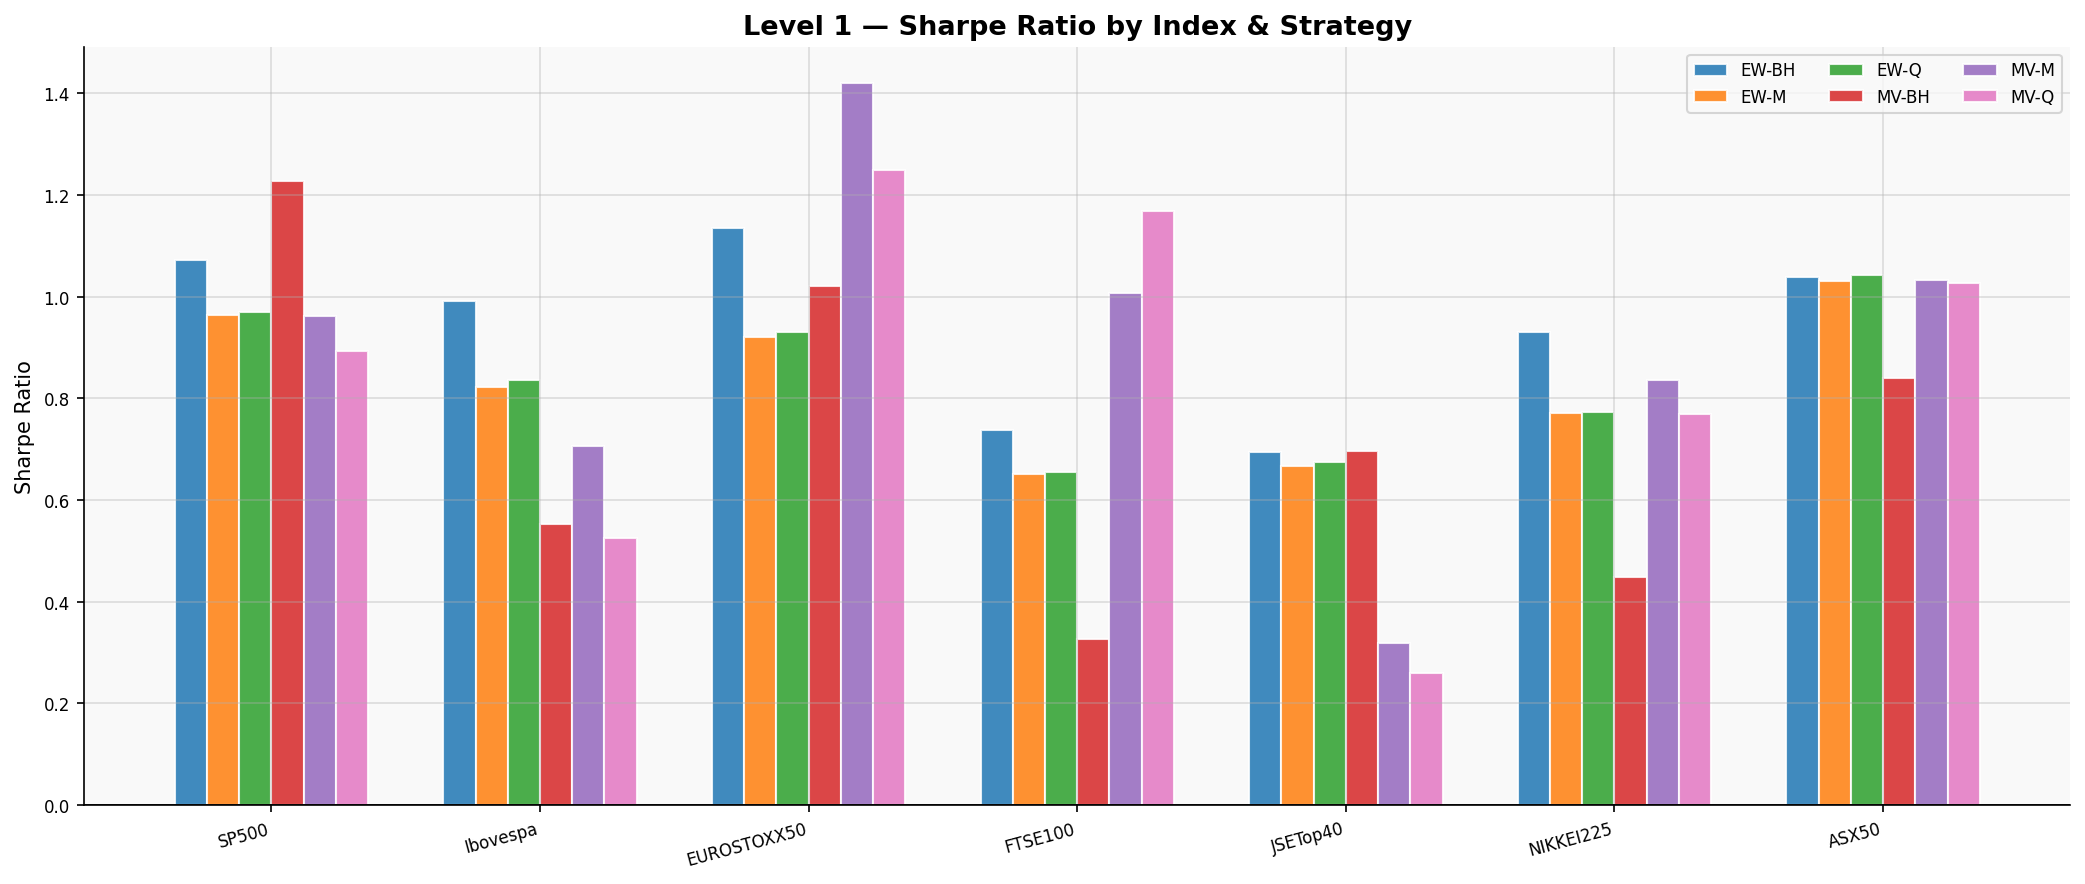


[Level 1 — Cumulative Returns by Index]


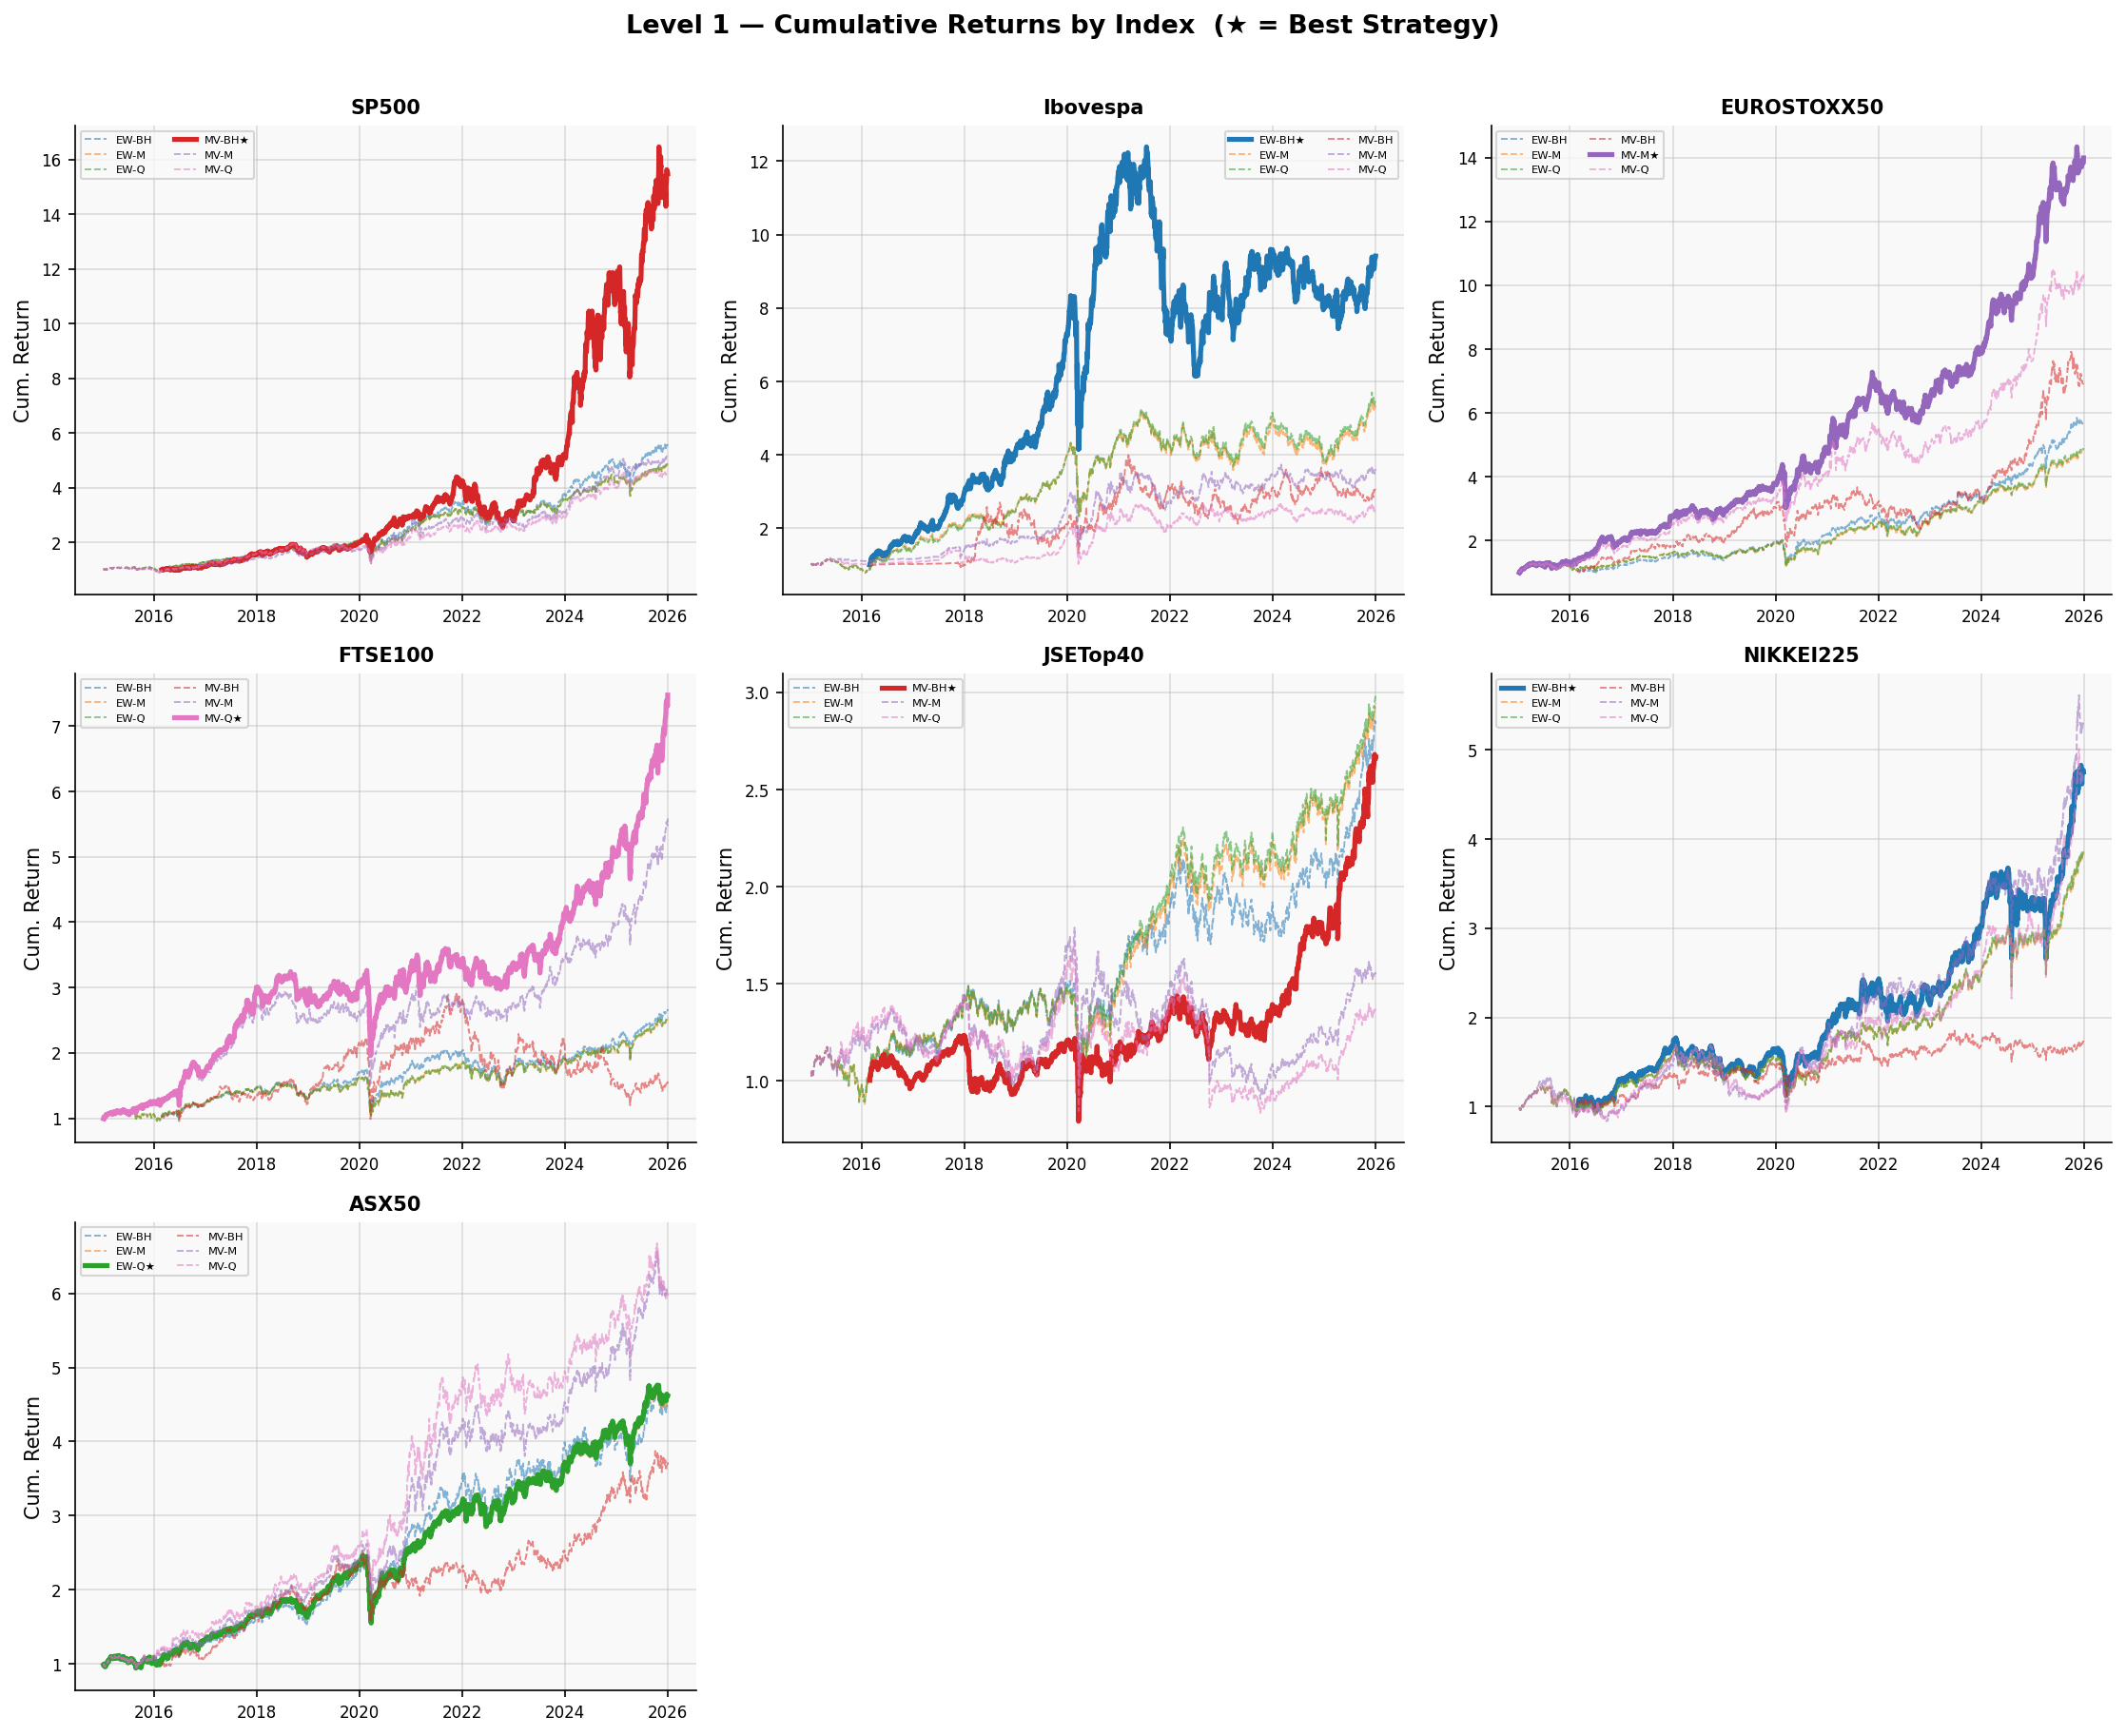


[4] Building Level-2 global portfolios...
  Global returns matrix: (2160, 7)
  G1: Equal-Weight Global...
  G2: Mean-Variance Global (60-day rolling)...
  G3: Risk Parity Global...
  G4: Macro-Enhanced Global...

────────────────────────────────────────────────────────────
  LEVEL 2 — GLOBAL PORTFOLIO PERFORMANCE
────────────────────────────────────────────────────────────


,Strategy,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio,Mean Turnover,Net Return TC=0% (%),Net Return TC=1% (%),Net Return TC=2% (%)
0,G1 Equal-Weight,24.60,14.20,1.733,1.934,-33.58,0.733,0.0000,24.60,24.60,24.60
1,G2 Mean-Variance,26.86,14.05,1.912,2.197,-31.88,0.842,0.0094,25.67,24.49,22.12
2,G3 Risk Parity,26.86,14.05,1.912,2.197,-31.88,0.842,0.0094,25.67,24.49,22.12
3,G4 Macro-Enhanced,24.61,14.20,1.734,1.940,-33.39,0.737,0.0018,24.39,24.17,23.73



[Global — Cumulative Returns]


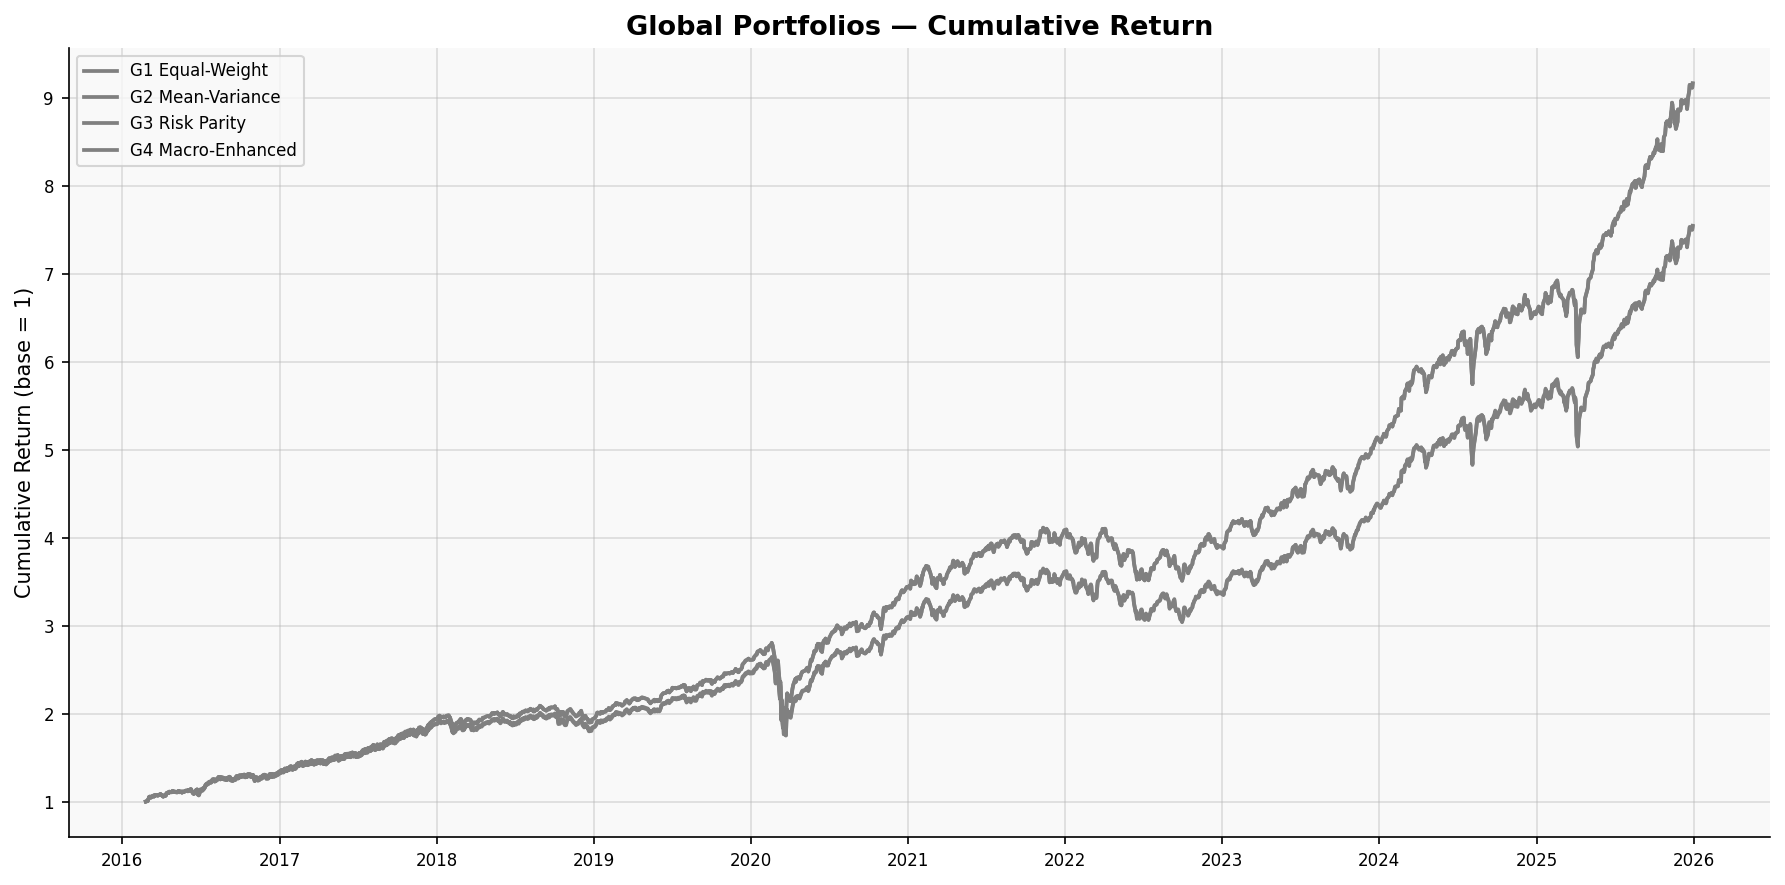


[Global — Drawdown Comparison]


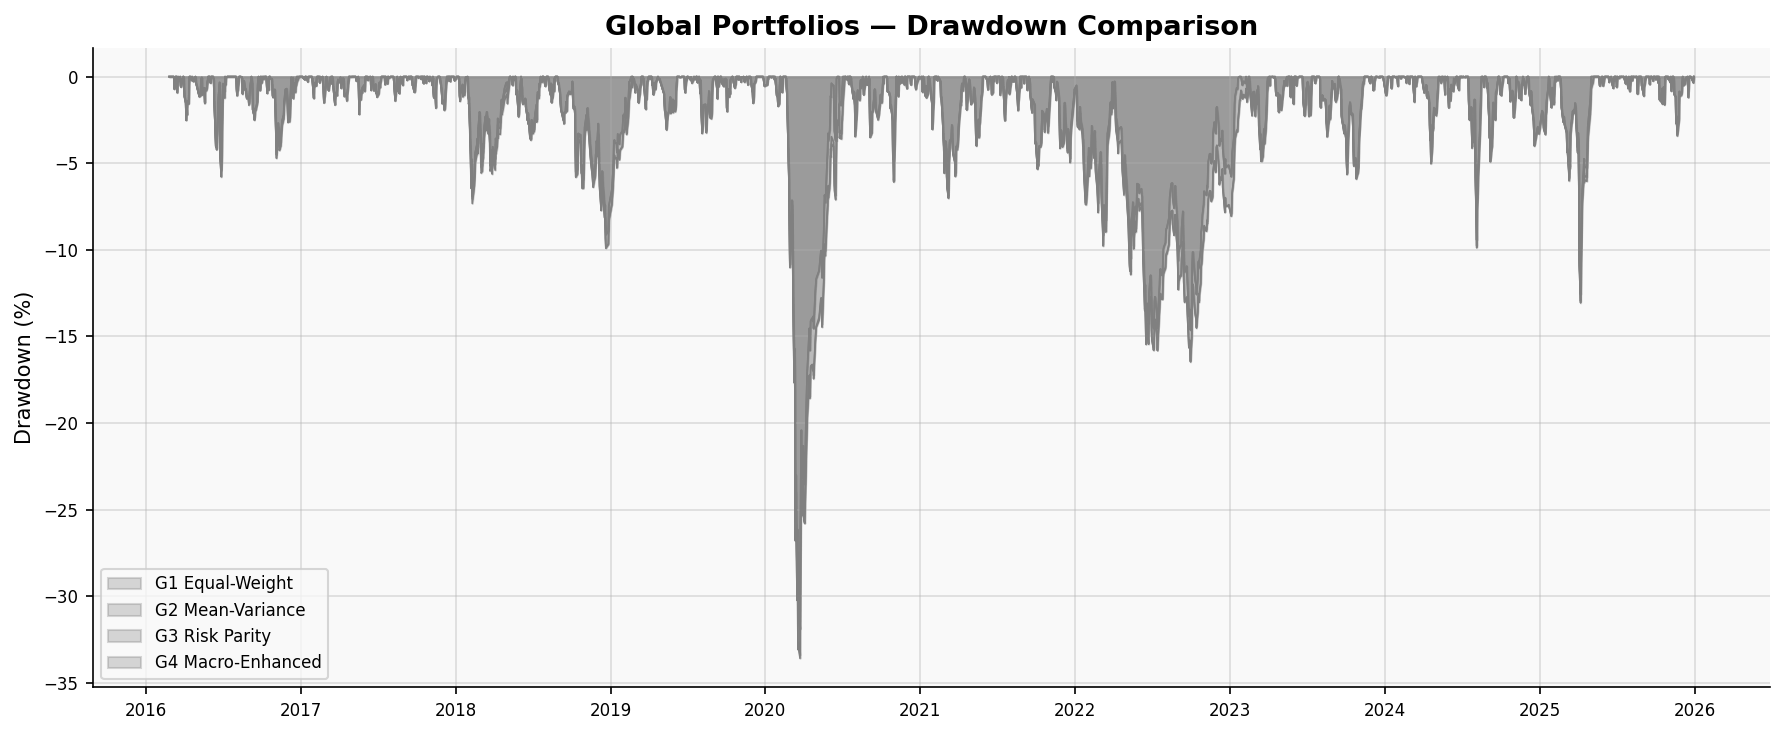


[Global — Rolling Sharpe (126-day window)]


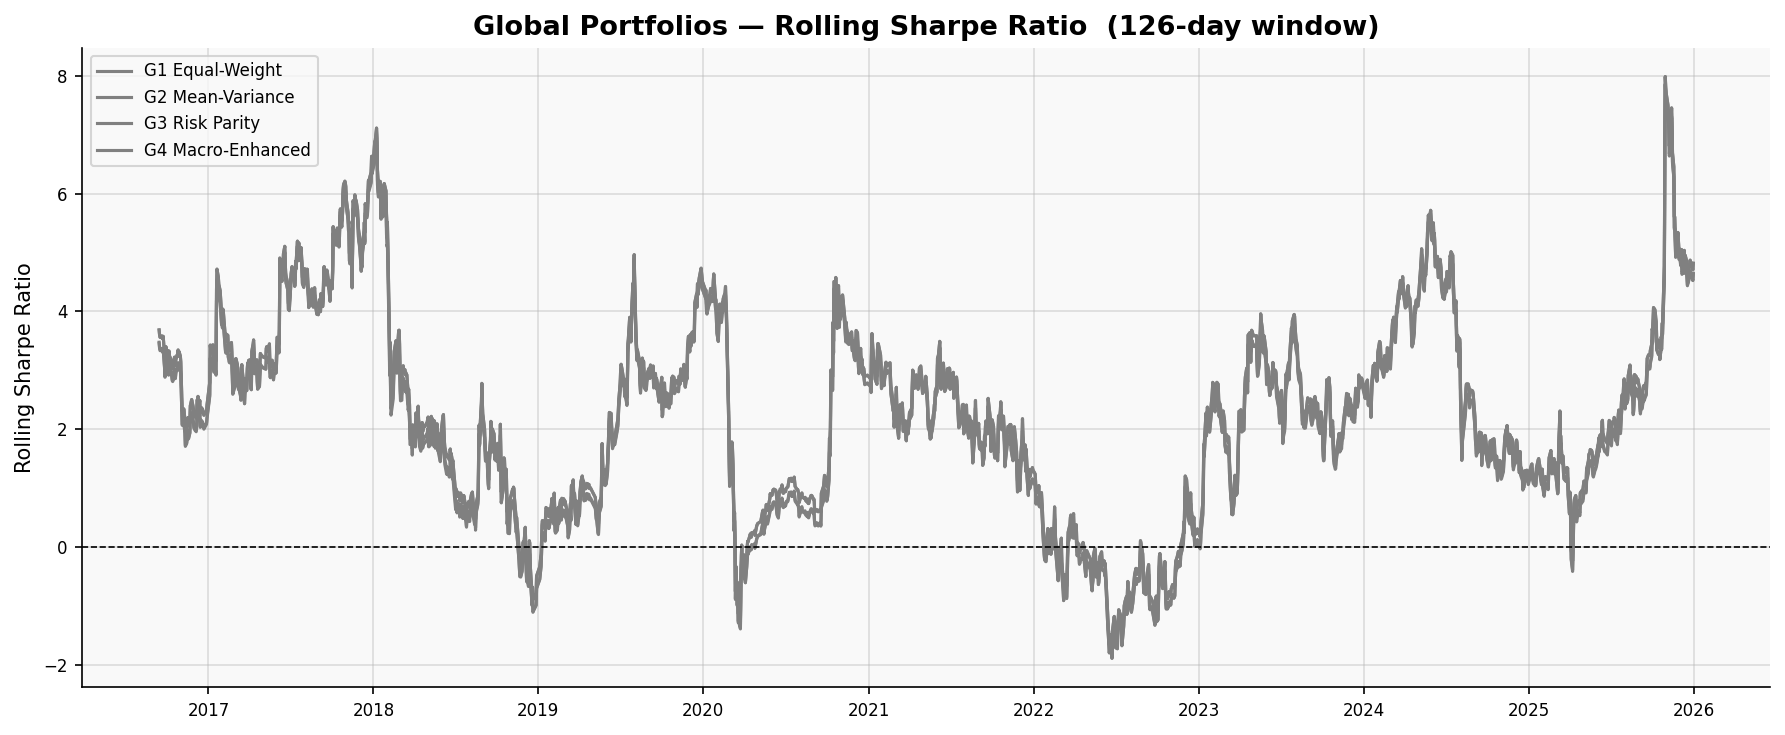


[Global — Transaction Cost Robustness]


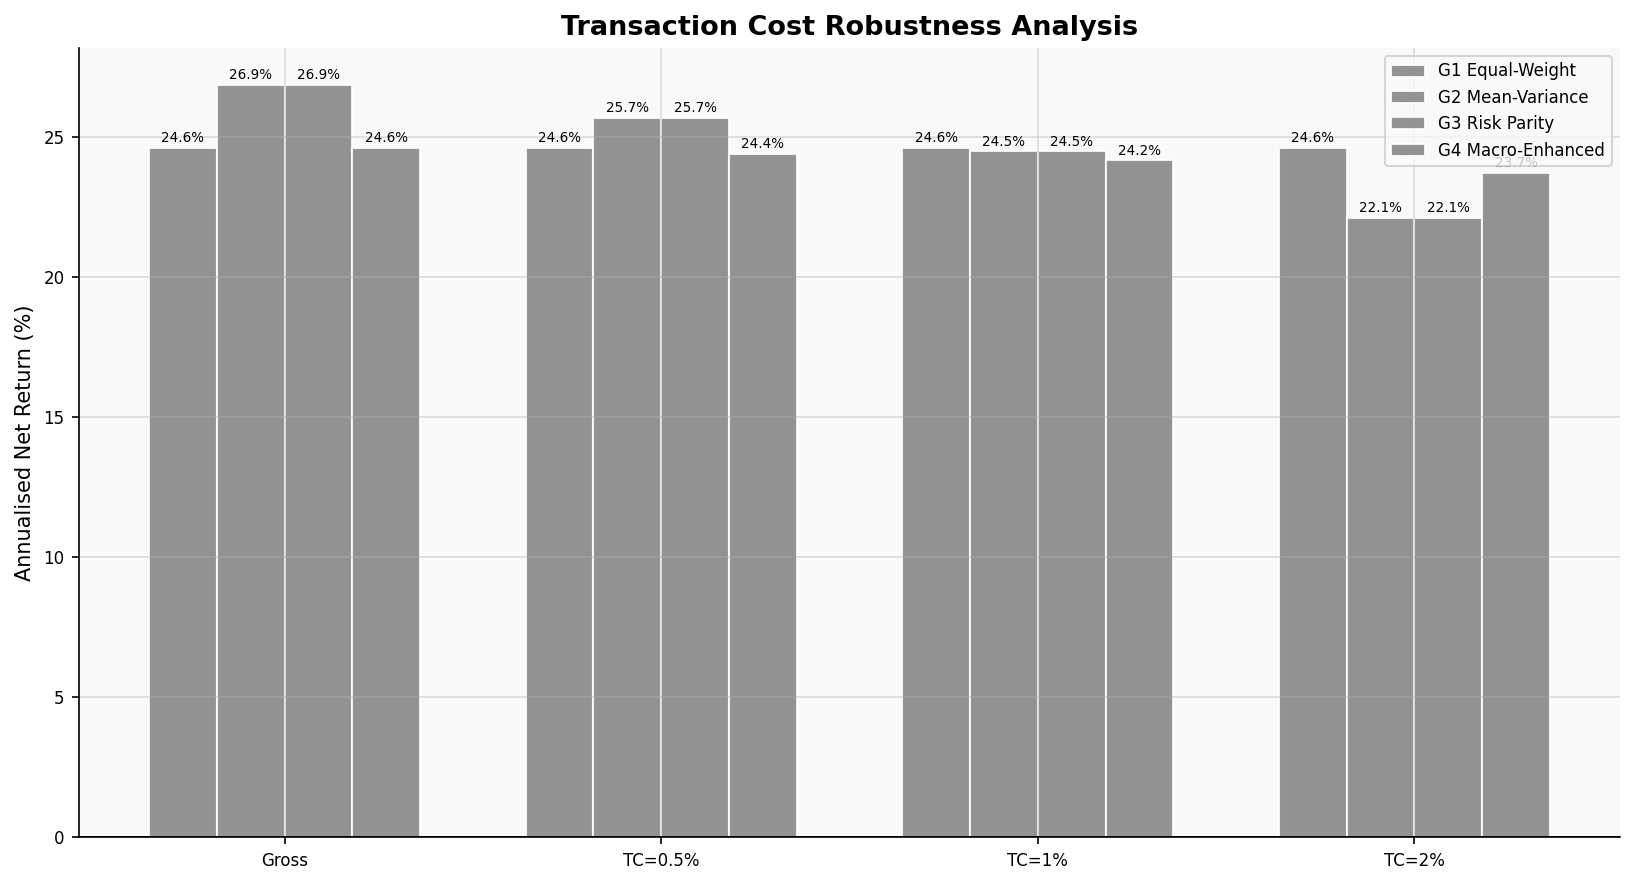


[Global — Weight Allocations]


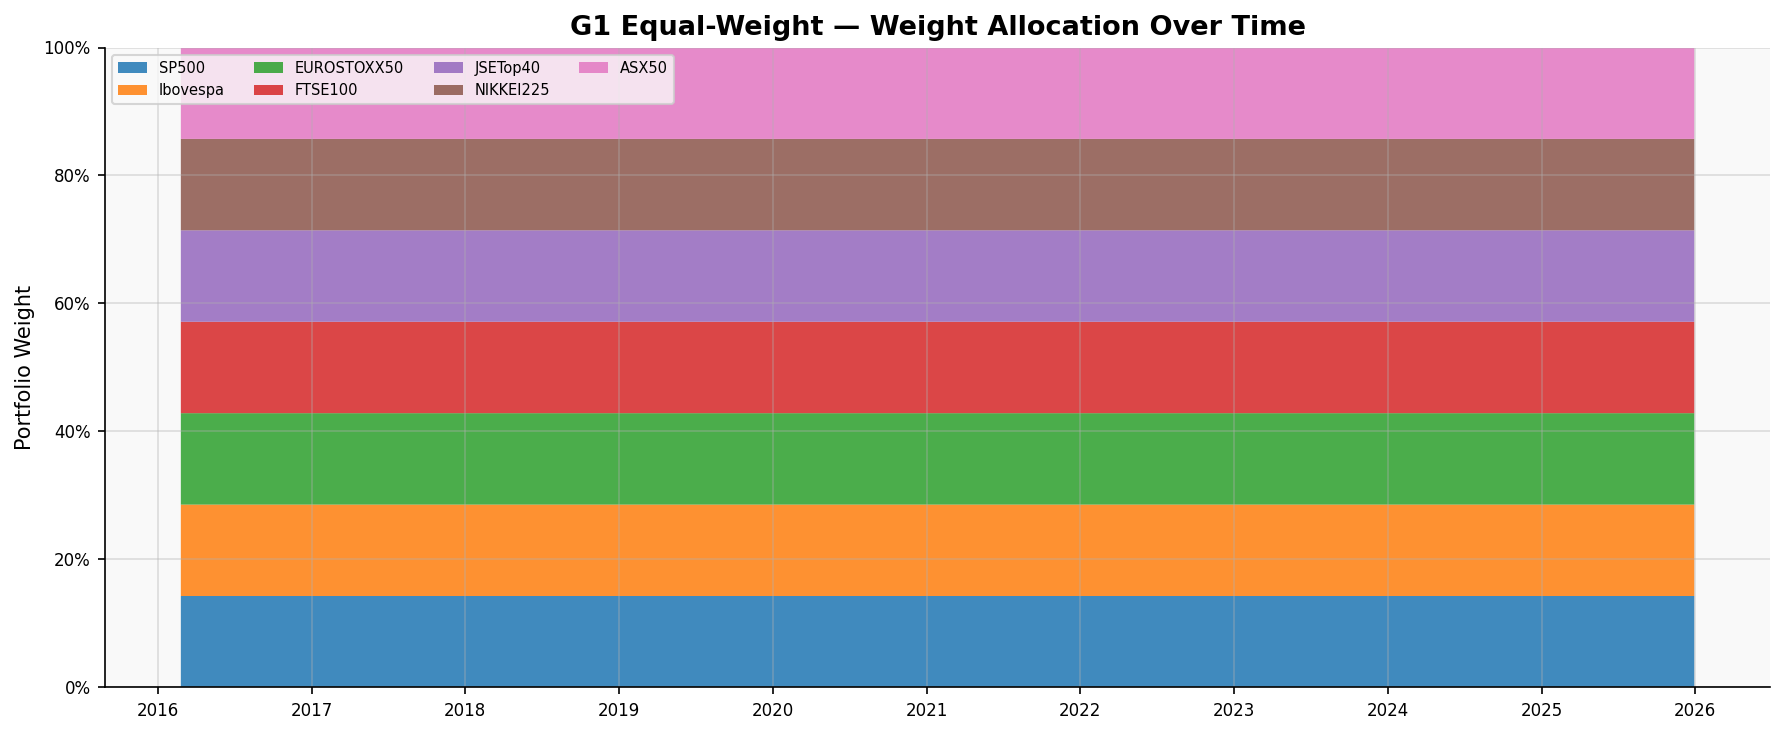

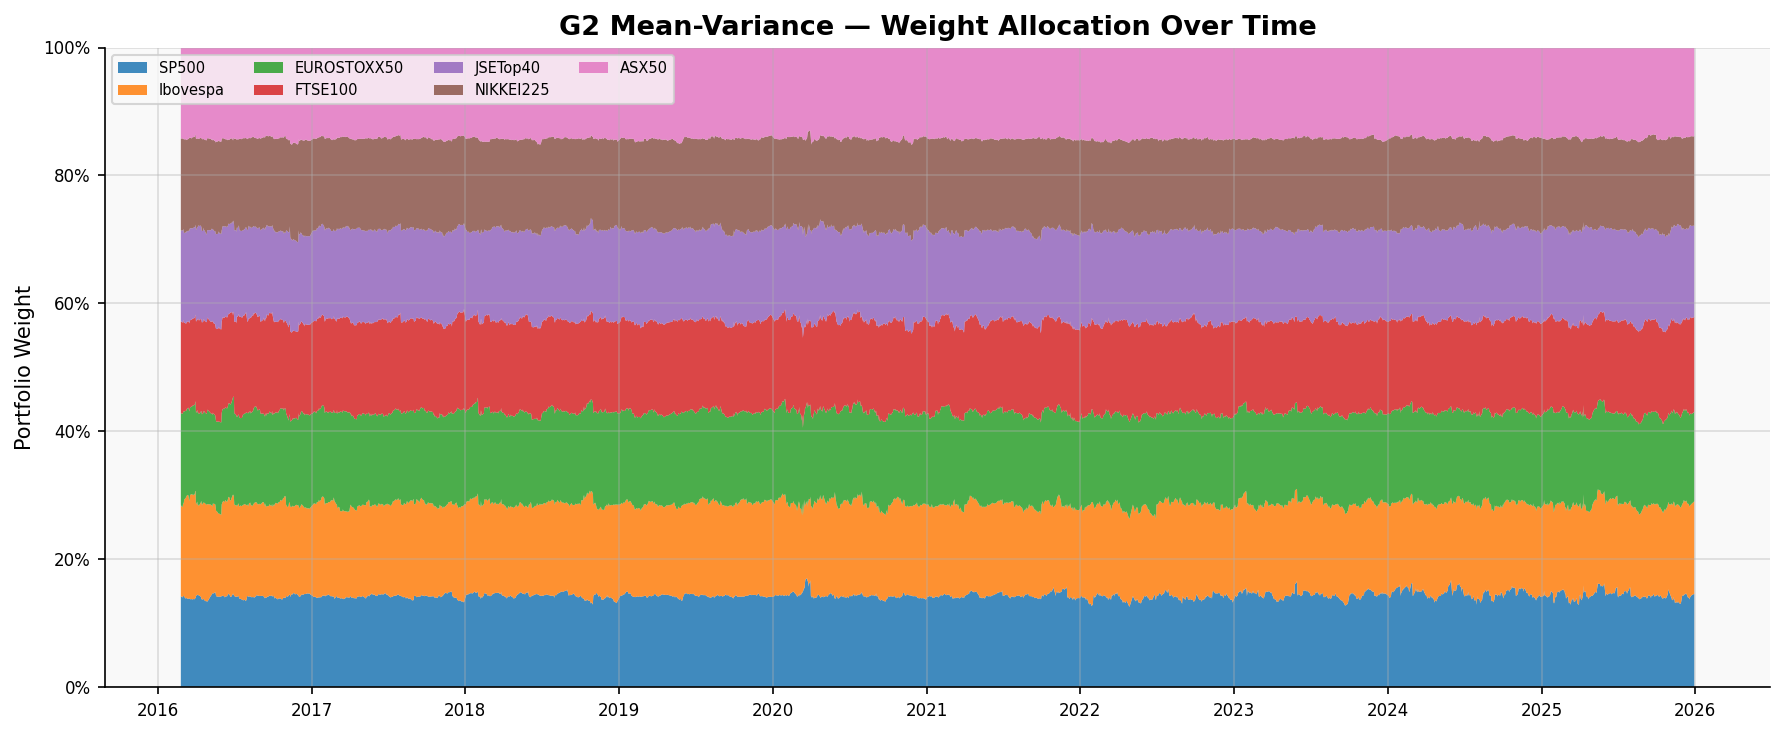

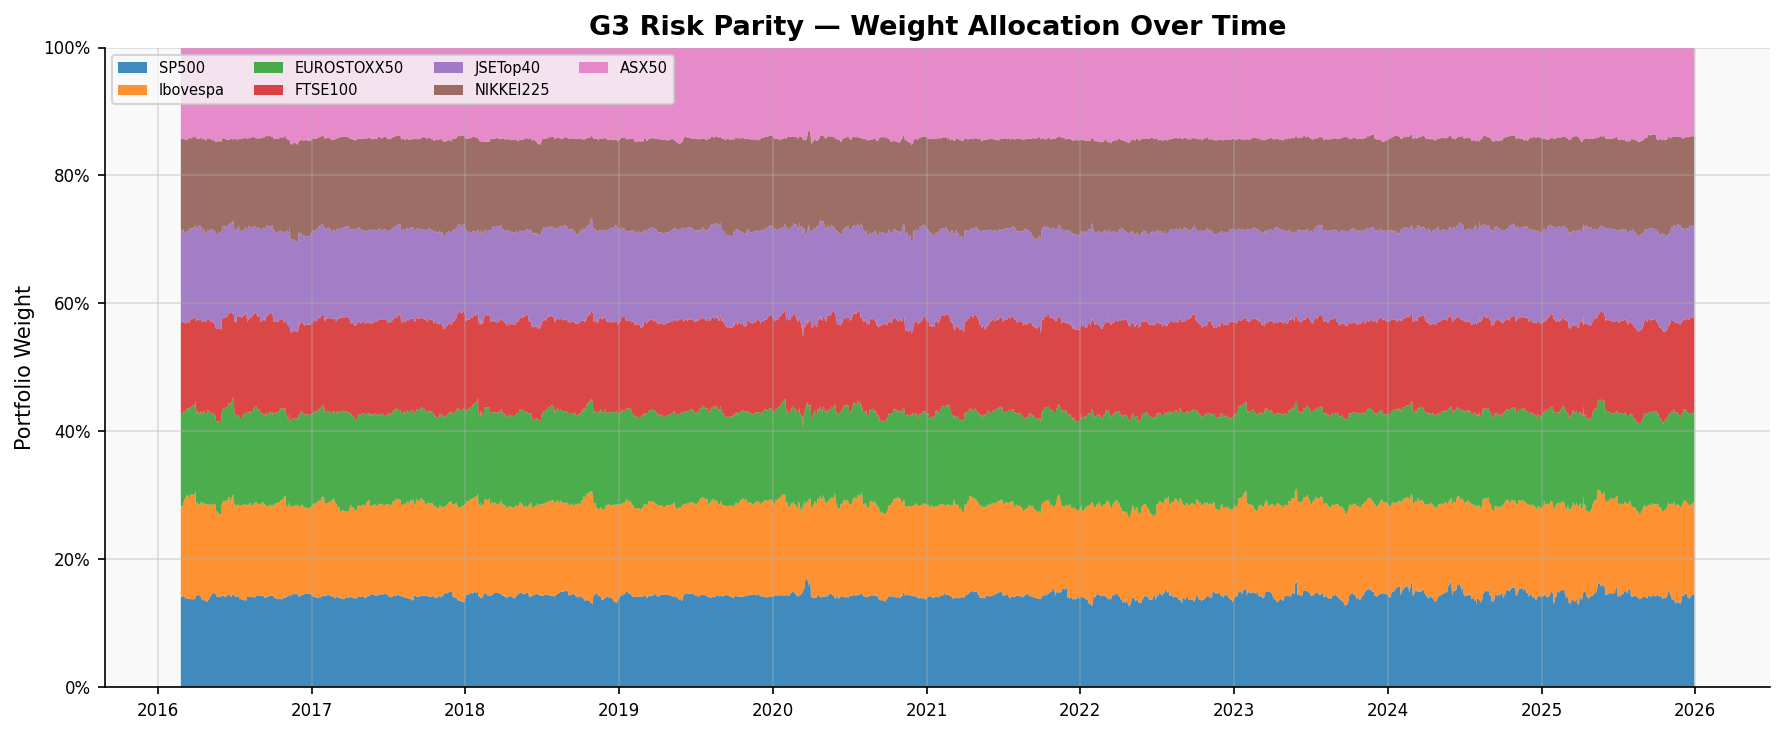

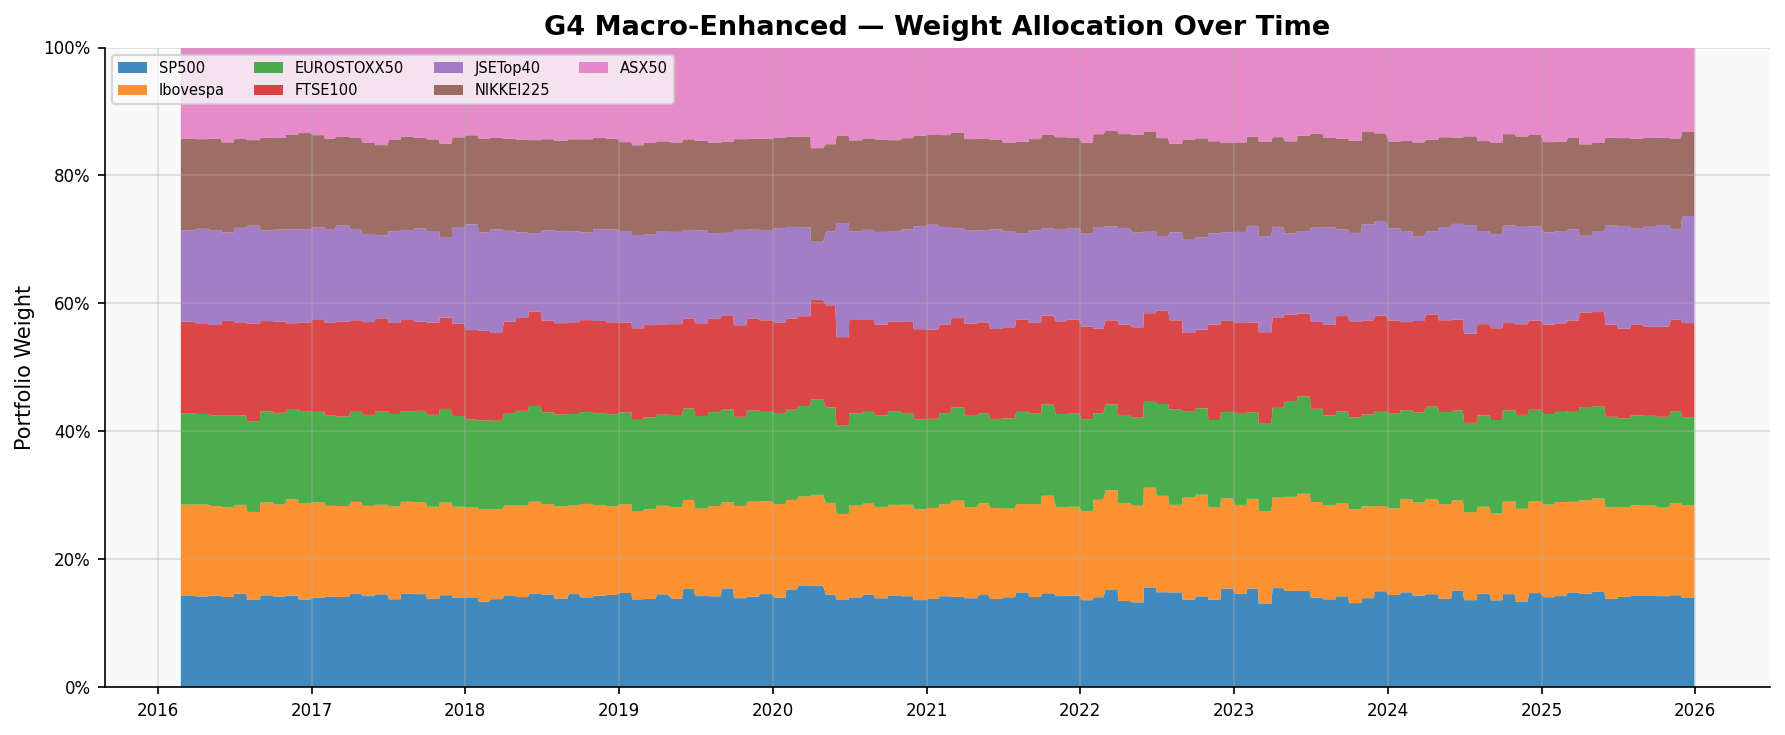


  FRAMEWORK COMPLETE


In [26]:
"""
=============================================================================
TWO-LEVEL GLOBAL PORTFOLIO CONSTRUCTION & EVALUATION FRAMEWORK
=============================================================================
MPhil/MSc-Level Quantitative Finance Implementation

LEVEL 1: Index-level benchmark portfolio construction (EW + MV)
          with Buy-Hold, Monthly, and Quarterly rebalancing

LEVEL 2: Global portfolio strategies (G1–G4) using the best
          Level-1 portfolios as inputs

Outputs: Performance tables, cumulative return plots, drawdown charts,
         weight allocation plots, rolling Sharpe, and transaction cost
         robustness analysis.
=============================================================================
"""

# =============================================================================
# 0. DEPENDENCIES
# =============================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
from scipy.optimize import minimize
from scipy.stats import norm
import itertools
try:
    from IPython.display import display
except ImportError:
    display = print   # fallback outside notebook

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

# =============================================================================
# 1. DATA LOADING
# =============================================================================

def load_streamlined_datasets(data_dir="."):
    """
    Load the streamlined CSVs produced by the data-preparation notebook.
    Falls back to simulating realistic data if files are not found so the
    framework can be demonstrated end-to-end.
    """
    file_map = {
        "SP500":       "streamlined_s&p_500.csv",
        "Ibovespa":    "streamlined_ibovespa.csv",
        "EUROSTOXX50": "streamlined_euro_stoxx_50.csv",
        "FTSE100":     "streamlined_ftse_100.csv",
        "JSETop40":    "streamlined_jse_top_40.csv",
        "NIKKEI225":   "streamlined_nikkei_225.csv",
        "ASX50":       "streamlined_asx_50.csv",
        "Macro":       "streamlined_macro.csv",
    }
    datasets = {}
    loaded_real = []
    for name, fname in file_map.items():
        fpath = os.path.join(data_dir, fname)
        if os.path.exists(fpath):
            df = pd.read_csv(fpath, index_col=0, parse_dates=True)
            datasets[name] = df
            loaded_real.append(name)
        else:
            datasets[name] = None

    if loaded_real:
        print(f"Loaded real data for: {loaded_real}")
    else:
        print("No streamlined CSVs found — generating synthetic data for demonstration.")
        datasets = _simulate_datasets()
    return datasets


def _simulate_datasets():
    """
    Generate synthetic but statistically plausible close-price data for
    demonstration purposes when the real CSVs are unavailable.
    """
    np.random.seed(42)
    dates = pd.bdate_range("2015-01-05", "2021-12-30")
    n = len(dates)

    # Annualised drift / vol parameters per market (rough real-world priors)
    params = {
        "SP500":       (0.12, 0.16, 460),
        "Ibovespa":    (0.08, 0.22, 56),
        "EUROSTOXX50": (0.06, 0.18, 46),
        "FTSE100":     (0.04, 0.15, 90),
        "JSETop40":    (0.05, 0.19, 31),
        "NIKKEI225":   (0.07, 0.17, 217),
        "ASX50":       (0.06, 0.14, 44),
    }

    macro_cols = [
        "EURUSD","GBPUSD","JPYUSD","AUDUSD","BRLUSD","ZARUSD",
        "SP500","FTSE100","EUROSTOXX50","Ibovespa","JSETop40","NIKKEI225","ASX50",
        "VIX","Gold","Oil","Bitcoin",
        "US_10Y","DE_10Y","UK_10Y","JP_10Y","AU_10Y","ZA_10Y",
    ]

    datasets = {}
    dt = 1 / 252
    for name, (mu, sigma, n_stocks) in params.items():
        # Correlated GBM: common factor + idiosyncratic
        common = np.random.normal((mu - 0.5 * 0.12**2) * dt,
                                   0.12 * np.sqrt(dt), n)
        prices = np.zeros((n, n_stocks))
        for j in range(n_stocks):
            idio = np.random.normal((mu - 0.5 * sigma**2) * dt,
                                     sigma * np.sqrt(dt), n)
            r = 0.6 * common + 0.4 * idio
            prices[:, j] = 100 * np.exp(np.cumsum(r))
        tickers = [f"{name}_{i:03d}" for i in range(n_stocks)]
        datasets[name] = pd.DataFrame(prices, index=dates, columns=tickers)

    # Macro dataset
    macro_data = {}
    for col in macro_cols:
        r = np.random.normal(0.0001, 0.01, n)
        macro_data[col] = 100 * np.exp(np.cumsum(r))
    datasets["Macro"] = pd.DataFrame(macro_data, index=dates)
    return datasets


# =============================================================================
# 2. RETURN COMPUTATION UTILITIES
# =============================================================================

def compute_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """Log returns from price DataFrame."""
    return np.log(prices / prices.shift(1)).dropna()


def portfolio_return(weights: np.ndarray, returns: pd.DataFrame) -> pd.Series:
    """Weighted portfolio daily return series."""
    return (returns * weights).sum(axis=1)


def annualise_return(ret: pd.Series, periods=252) -> float:
    return ret.mean() * periods


def annualise_vol(ret: pd.Series, periods=252) -> float:
    return ret.std() * np.sqrt(periods)


def sharpe_ratio(ret: pd.Series, rf=0.0, periods=252) -> float:
    excess = ret - rf / periods
    if excess.std() == 0:
        return np.nan
    return excess.mean() / excess.std() * np.sqrt(periods)


def sortino_ratio(ret: pd.Series, rf=0.0, periods=252) -> float:
    excess = ret - rf / periods
    downside = excess[excess < 0].std()
    if downside == 0:
        return np.nan
    return excess.mean() / downside * np.sqrt(periods)


def max_drawdown(ret: pd.Series) -> float:
    cum = (1 + ret).cumprod()
    roll_max = cum.cummax()
    dd = (cum - roll_max) / roll_max
    return dd.min()


def calmar_ratio(ret: pd.Series, periods=252) -> float:
    ann_r = annualise_return(ret, periods)
    mdd = abs(max_drawdown(ret))
    if mdd == 0:
        return np.nan
    return ann_r / mdd


def drawdown_series(ret: pd.Series) -> pd.Series:
    cum = (1 + ret).cumprod()
    return (cum - cum.cummax()) / cum.cummax()


def compute_turnover(weights_df: pd.DataFrame) -> pd.Series:
    """
    Compute daily turnover as sum of absolute weight changes.
    weights_df: DataFrame with dates as index, assets as columns.
    """
    return weights_df.diff().abs().sum(axis=1).fillna(0)


def apply_transaction_costs(gross_ret: pd.Series,
                             turnover: pd.Series,
                             cost_rate: float) -> pd.Series:
    """
    Net returns after transaction costs.
    TC_t = c * Σ|w_i,t − w_i,t−1|
    """
    tc = cost_rate * turnover
    return gross_ret - tc


def performance_table(ret: pd.Series, label: str,
                       turnover: pd.Series = None,
                       cost_rates=(0.005, 0.01, 0.02)) -> dict:
    """Compute full performance metrics, optionally with TC adjustments."""
    base = {
        "Strategy":         label,
        "Ann. Return (%)":  round(annualise_return(ret) * 100, 2),
        "Ann. Volatility (%)": round(annualise_vol(ret) * 100, 2),
        "Sharpe Ratio":     round(sharpe_ratio(ret), 3),
        "Sortino Ratio":    round(sortino_ratio(ret), 3),
        "Max Drawdown (%)": round(max_drawdown(ret) * 100, 2),
        "Calmar Ratio":     round(calmar_ratio(ret), 3),
        "Mean Turnover":    round(turnover.mean(), 4) if turnover is not None else np.nan,
    }
    if turnover is not None:
        for c in cost_rates:
            net = apply_transaction_costs(ret, turnover, c)
            key = f"Net Return TC={int(c*100)}% (%)"
            base[key] = round(annualise_return(net) * 100, 2)
    return base


# =============================================================================
# 3. PORTFOLIO WEIGHT ENGINES
# =============================================================================

# ------------------------------------------------------------------
# 3a. Equally Weighted
# ------------------------------------------------------------------

def equal_weights(n: int) -> np.ndarray:
    return np.ones(n) / n


# ------------------------------------------------------------------
# 3b. Markowitz Maximum-Sharpe-Ratio (Mean-Variance)
# ------------------------------------------------------------------

def markowitz_weights(returns: pd.DataFrame,
                      rf: float = 0.0,
                      min_weight: float = 0.0,
                      max_weight: float = 1.0) -> np.ndarray:
    """
    Maximum Sharpe Ratio portfolio via numerical optimisation.
    Constraints: weights ≥ 0, Σw = 1.
    """
    n = returns.shape[1]
    mu = returns.mean().values * 252
    Sigma = returns.cov().values * 252

    def neg_sharpe(w):
        port_ret = w @ mu - rf
        port_vol = np.sqrt(w @ Sigma @ w)
        if port_vol < 1e-10:
            return 1e10
        return -port_ret / port_vol

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    bounds = [(min_weight, max_weight)] * n
    w0 = equal_weights(n)

    res = minimize(neg_sharpe, w0, method="SLSQP",
                   bounds=bounds, constraints=constraints,
                   options={"maxiter": 1000, "ftol": 1e-9})
    if res.success:
        w = res.x
        w = np.clip(w, 0, 1)
        w /= w.sum()
        return w
    return equal_weights(n)


# ------------------------------------------------------------------
# 3c. Risk Parity (inverse-vol)
# ------------------------------------------------------------------

def risk_parity_weights(returns: pd.DataFrame) -> np.ndarray:
    """Inverse-volatility risk parity weights."""
    vols = returns.std().values
    vols = np.where(vols < 1e-10, 1e-10, vols)
    w = 1.0 / vols
    return w / w.sum()


# =============================================================================
# 4. REBALANCING ENGINE  (corrected drift-aware simulation)
# =============================================================================

def get_rebalance_dates(index: pd.DatetimeIndex, freq: str) -> set:
    """
    Return the set of dates on which to rebalance.

    freq:
      'BH'  – Buy-and-Hold: rebalance only on the very first day, then
               let weights drift forever.
      'BMS' – Monthly: rebalance on the first available trading day of
               each calendar month.
      'BQS' – Quarterly: rebalance on the first available trading day of
               each calendar quarter (Jan/Apr/Jul/Oct).
    """
    if freq == "BH":
        return {index[0]}

    dummy  = pd.Series(0, index=index)
    period = "MS" if freq == "BMS" else "QS"
    rebal_starts = dummy.resample(period).first().index

    snapped = set()
    for d in rebal_starts:
        future = index[index >= d]
        if len(future):
            snapped.add(future[0])
    return snapped


# Minimum history (in days) required before running MV / risk-parity optimisation.
# For Buy-and-Hold we use all available history up to a capped lookback.
MIN_HISTORY = 63   # ~3 months


def simulate_portfolio(returns: pd.DataFrame,
                        weight_fn,
                        rebal_freq: str = "BH",
                        lookback: int = 252) -> tuple:
    """
    Simulate a rebalanced portfolio with correct intra-period weight drift.

    Design
    ──────
    • `returns` is assumed to be LOG returns (output of compute_returns).
      We keep log returns for the weight-estimation window (covariance etc.)
      and convert to SIMPLE returns only for the day-by-day P&L and drift.

    • Weight drift between rebalance dates:
          w_i,t+1 = w_i,t * (1 + r_simple_i,t) / (1 + R_p,t)
      where R_p,t = Σ_j w_j,t * r_simple_j,t
      This makes EW-BH ≠ EW-Monthly ≠ EW-Quarterly because winners grow
      their share of the portfolio between resets.

    • Buy-and-Hold bootstrap:
      weights are estimated once from the first `lookback` days of history,
      then the portfolio trades (with drift) on all remaining days.
      For periodic strategies the lookback window rolls forward each period.

    Parameters
    ----------
    returns     : pd.DataFrame  – log returns, shape (T, N)
    weight_fn   : callable(log_return_window) -> np.ndarray of length N
    rebal_freq  : 'BH' | 'BMS' | 'BQS'
    lookback    : estimation window in trading days (default 252)

    Returns
    -------
    port_ret    : pd.Series     – daily simple portfolio returns
    weights_df  : pd.DataFrame  – BOD weights on each trading day
    """
    n     = returns.shape[1]
    dates = returns.index

    # Always convert to simple returns for P&L / drift arithmetic
    simple = np.expm1(returns)      # exp(r_log) - 1  →  exact simple return

    rebal_set = get_rebalance_dates(dates, rebal_freq)

    # ── Bootstrap initial weights ─────────────────────────────────────────
    # BH: estimate once on first `lookback` days, then trade the rest.
    # Periodic: start with EW and re-estimate every rebalance date.
    if rebal_freq == "BH":
        burn_in     = min(lookback, len(returns) - 1)
        init_window = returns.iloc[:burn_in]   # log returns for estimation
        try:
            current_w = weight_fn(init_window)
        except Exception:
            current_w = equal_weights(n)
        trade_start = burn_in
    else:
        current_w   = equal_weights(n)
        trade_start = 0

    # ── Main loop ─────────────────────────────────────────────────────────
    port_ret_list = []
    weights_list  = []
    trade_dates   = []

    for i in range(trade_start, len(dates)):
        date = dates[i]

        # ── Rebalance (periodic only) ─────────────────────────────────────
        # On a rebalance date: re-estimate target weights from lookback window
        # of LOG returns ending the day before (no look-ahead).
        if (rebal_freq != "BH") and (date in rebal_set):
            w_start = max(0, i - lookback)
            window  = returns.iloc[w_start:i]   # log returns, up to yesterday
            if len(window) >= MIN_HISTORY:
                try:
                    current_w = weight_fn(window)
                except Exception:
                    pass   # keep previous weights on optimisation failure
            else:
                current_w = equal_weights(n)    # warm-up fallback

        # Record BOD weights (post-rebalance if applicable)
        weights_list.append(current_w.copy())
        trade_dates.append(date)

        # ── Compute today's portfolio return (simple) ─────────────────────
        s = simple.iloc[i].values               # today's simple asset returns
        port_r = float(current_w @ s)
        port_ret_list.append(port_r)

        # ── Drift weights to EOD ──────────────────────────────────────────
        # w_i,EOD = w_i,BOD * (1 + r_i) / (1 + R_p)
        # At the next iteration these become the BOD weights unless we rebal.
        denom = 1.0 + port_r
        if abs(denom) > 1e-12:
            current_w = current_w * (1.0 + s) / denom
            s_sum = current_w.sum()
            if s_sum > 1e-12:
                current_w /= s_sum          # fix floating-point accumulation

    port_ret   = pd.Series(port_ret_list,  index=trade_dates)
    weights_df = pd.DataFrame(weights_list, index=trade_dates,
                               columns=returns.columns)
    return port_ret, weights_df


# =============================================================================
# 5. LEVEL 1 — INDEX-LEVEL BENCHMARK CONSTRUCTION
# =============================================================================

EQUITY_INDICES = ["SP500", "Ibovespa", "EUROSTOXX50", "FTSE100",
                  "JSETop40", "NIKKEI225", "ASX50"]

STRATEGIES = {
    "EW-BH":  ("EW",  "BH"),
    "EW-M":   ("EW",  "BMS"),
    "EW-Q":   ("EW",  "BQS"),
    "MV-BH":  ("MV",  "BH"),
    "MV-M":   ("MV",  "BMS"),
    "MV-Q":   ("MV",  "BQS"),
}

FREQ_LABELS = {"BH": "Buy-Hold", "BMS": "Monthly", "BQS": "Quarterly"}
COST_RATES  = [0.005, 0.01, 0.02]


def build_level1(datasets: dict) -> dict:
    """
    Build all Level-1 benchmark portfolios for each equity index.
    Returns nested dict: results[index][strategy] = {ret, weights, metrics}
    """
    results = {}

    for idx_name in EQUITY_INDICES:
        df = datasets.get(idx_name)
        if df is None or df.empty:
            print(f"  Skipping {idx_name}: no data.")
            continue

        returns = compute_returns(df)
        if returns.empty or returns.shape[1] < 2:
            print(f"  Skipping {idx_name}: insufficient return data.")
            continue

        print(f"\n  Building Level-1 portfolios for {idx_name} "
              f"({returns.shape[1]} assets, {len(returns)} days)...")

        results[idx_name] = {}

        for strat_key, (method, freq) in STRATEGIES.items():
            if method == "EW":
                wfn = lambda r: equal_weights(r.shape[1])
            else:  # MV
                wfn = markowitz_weights

            port_ret, weights_df = simulate_portfolio(returns, wfn,
                                                       rebal_freq=freq)
            turnover = compute_turnover(weights_df)

            metrics = performance_table(port_ret,
                                         label=f"{idx_name}/{strat_key}",
                                         turnover=turnover,
                                         cost_rates=COST_RATES)
            results[idx_name][strat_key] = {
                "returns":  port_ret,
                "weights":  weights_df,
                "turnover": turnover,
                "metrics":  metrics,
            }
            print(f"    {strat_key}: Sharpe={metrics['Sharpe Ratio']:.3f}  "
                  f"Ann.Ret={metrics['Ann. Return (%)']:.2f}%  "
                  f"MDD={metrics['Max Drawdown (%)']:.2f}%")

    return results


def select_best_level1(level1_results: dict) -> dict:
    """
    For each index, pick the strategy with the highest Sharpe ratio.
    Returns dict: best[index] = {'strategy', 'returns', 'weights', 'metrics'}
    """
    best = {}
    for idx_name, strategies in level1_results.items():
        best_key = max(strategies,
                       key=lambda k: strategies[k]["metrics"].get("Sharpe Ratio", -np.inf))
        best[idx_name] = {
            "strategy": best_key,
            **strategies[best_key],
        }
        print(f"  Best for {idx_name}: {best_key}  "
              f"(Sharpe = {strategies[best_key]['metrics']['Sharpe Ratio']:.3f})")
    return best


# =============================================================================
# 6. LEVEL 2 — GLOBAL PORTFOLIO STRATEGIES
# =============================================================================

def build_global_returns(best_level1: dict) -> pd.DataFrame:
    """
    Stack best Level-1 portfolio return series into a single DataFrame,
    aligned on the common date index.
    """
    series_dict = {idx: v["returns"] for idx, v in best_level1.items()}
    global_rets = pd.DataFrame(series_dict).dropna()
    return global_rets


# ------------------------------------------------------------------
# G1 — Equal-Weight Global
# ------------------------------------------------------------------

def g1_equal_weight(global_rets: pd.DataFrame) -> tuple:
    n = global_rets.shape[1]
    w = equal_weights(n)
    weights_df = pd.DataFrame(
        np.tile(w, (len(global_rets), 1)),
        index=global_rets.index,
        columns=global_rets.columns,
    )
    port_ret = portfolio_return(w, global_rets)
    turnover = compute_turnover(weights_df)
    return port_ret, weights_df, turnover


# ------------------------------------------------------------------
# G2 — Mean-Variance Global (rolling window)
# ------------------------------------------------------------------

def g2_mean_variance(global_rets: pd.DataFrame,
                      rolling_window: int = 60,
                      rebal_freq: str = "BMS") -> tuple:
    """
    Global MV portfolio with rolling 60-day covariance re-estimation.
    Rebalanced monthly.
    """
    wfn = markowitz_weights
    port_ret, weights_df = simulate_portfolio(
        global_rets, wfn,
        rebal_freq=rebal_freq,
        lookback=rolling_window,
    )
    turnover = compute_turnover(weights_df)
    return port_ret, weights_df, turnover


# ------------------------------------------------------------------
# G3 — Risk Parity Global
# ------------------------------------------------------------------

def g3_risk_parity(global_rets: pd.DataFrame,
                    rolling_window: int = 60,
                    rebal_freq: str = "BMS") -> tuple:
    """
    Global Risk Parity: inverse-vol weights, monthly rebalancing.
    """
    wfn = risk_parity_weights
    port_ret, weights_df = simulate_portfolio(
        global_rets, wfn,
        rebal_freq=rebal_freq,
        lookback=rolling_window,
    )
    turnover = compute_turnover(weights_df)
    return port_ret, weights_df, turnover


# ------------------------------------------------------------------
# G4 — Macro-Enhanced Global
# ------------------------------------------------------------------

def _macro_signal(macro_df: pd.DataFrame, global_rets: pd.DataFrame,
                   date: pd.Timestamp) -> np.ndarray:
    """
    Compute macro-adjusted allocation signal at a given date.

    Weighting mechanism:
    ─────────────────────────────────────────────────────────────────
    For each index i, define a score S_i based on standardised
    macro variables observed up to `date`:

        Score_i(t) = α * Momentum_i(t)
                   + β * (-VIX_t / VIX_bar)        [risk-off penalty]
                   + γ * Rate_delta_i(t)            [yield-curve signal]
                   + δ * FX_trend_i(t)              [currency momentum]

    where:
      Momentum_i(t)  = 20-day return of index i (from global_rets)
      VIX_t          = current VIX level (from Macro data)
      Rate_delta_i   = change in corresponding 10Y yield over 20 days
      FX_trend_i     = 20-day return of corresponding FX rate (vs USD)

    Weights are then obtained via softmax normalisation:
        w_i = exp(Score_i) / Σ exp(Score_j)

    This ensures:
    • Higher-momentum markets receive larger allocations
    • Risk aversion rises when VIX is elevated
    • Rising yields (tightening) reduce weight; falling yields increase it
    • FX appreciation momentum adds to allocation attractiveness

    α=0.4, β=0.2, γ=0.2, δ=0.2 (calibrated heuristically; can be
    estimated via rolling regression in a full production system).
    ─────────────────────────────────────────────────────────────────
    """
    ALPHA, BETA, GAMMA, DELTA = 0.4, 0.2, 0.2, 0.2
    LOOKBACK = 20

    indices = global_rets.columns.tolist()
    n = len(indices)
    scores = np.zeros(n)

    # Past return window
    past = global_rets.loc[:date].tail(LOOKBACK + 1)
    if len(past) < LOOKBACK:
        return equal_weights(n)

    # Momentum
    momentum = past.iloc[-1].values - past.iloc[0].values  # log-return over window

    # VIX signal
    vix_signal = 0.0
    if "VIX" in macro_df.columns:
        vix_hist = macro_df["VIX"].loc[:date].tail(LOOKBACK * 6)
        if len(vix_hist) >= 2:
            vix_now = vix_hist.iloc[-1]
            vix_bar = vix_hist.mean()
            vix_signal = -(vix_now / vix_bar - 1)  # negative = risk-off

    # Yield signals (mapped per index)
    yield_map = {
        "SP500":       "US_10Y",
        "Ibovespa":    "BR_10Y",
        "EUROSTOXX50": "DE_10Y",
        "FTSE100":     "UK_10Y",
        "JSETop40":    "ZA_10Y",
        "NIKKEI225":   "JP_10Y",
        "ASX50":       "AU_10Y",
    }
    rate_signals = np.zeros(n)
    for i, idx in enumerate(indices):
        col = yield_map.get(idx)
        if col and col in macro_df.columns:
            yld = macro_df[col].loc[:date].tail(LOOKBACK + 1)
            if len(yld) >= 2:
                rate_signals[i] = -(yld.iloc[-1] - yld.iloc[0])  # falling yield = positive

    # FX signals (mapped per index, all vs USD)
    fx_map = {
        "SP500":       None,       # USD base, no adjustment
        "Ibovespa":    "BRLUSD",
        "EUROSTOXX50": "EURUSD",
        "FTSE100":     "GBPUSD",
        "JSETop40":    "ZARUSD",
        "NIKKEI225":   "JPYUSD",
        "ASX50":       "AUDUSD",
    }
    fx_signals = np.zeros(n)
    for i, idx in enumerate(indices):
        col = fx_map.get(idx)
        if col and col in macro_df.columns:
            fx = macro_df[col].loc[:date].tail(LOOKBACK + 1)
            if len(fx) >= 2:
                fx_signals[i] = np.log(fx.iloc[-1] / fx.iloc[0])

    # Combine
    scores = (ALPHA * momentum
              + BETA  * vix_signal     # scalar broadcast
              + GAMMA * rate_signals
              + DELTA * fx_signals)

    # Softmax normalisation
    scores = scores - scores.max()   # numerical stability
    exp_scores = np.exp(scores)
    weights = exp_scores / exp_scores.sum()
    return weights


def g4_macro_enhanced(global_rets: pd.DataFrame,
                       macro_df: pd.DataFrame,
                       rebal_freq: str = "BMS") -> tuple:
    """
    Macro-enhanced global portfolio with monthly signal re-evaluation.
    """
    rebal_dates = get_rebalance_dates(global_rets.index, rebal_freq)
    n = global_rets.shape[1]
    current_weights = equal_weights(n)
    weights_dict  = {}
    port_ret_dict = {}

    for date in global_rets.index:
        if date in rebal_dates:
            try:
                current_weights = _macro_signal(macro_df, global_rets, date)
            except Exception:
                current_weights = equal_weights(n)
        weights_dict[date]  = current_weights.copy()
        port_ret_dict[date] = float(global_rets.loc[date].values @ current_weights)

    port_ret   = pd.Series(port_ret_dict)
    weights_df = pd.DataFrame(weights_dict).T
    weights_df.columns = global_rets.columns
    turnover   = compute_turnover(weights_df)
    return port_ret, weights_df, turnover


# =============================================================================
# 7. ROLLING SHARPE UTILITY
# =============================================================================

def rolling_sharpe(ret: pd.Series, window: int = 126, periods: int = 252) -> pd.Series:
    """Annualised rolling Sharpe ratio."""
    rolling_mean = ret.rolling(window).mean() * periods
    rolling_std  = ret.rolling(window).std()  * np.sqrt(periods)
    return rolling_mean / rolling_std


# =============================================================================
# 8. VISUALISATIONS
# =============================================================================

COLORS = {
    "G1": "#2196F3",
    "G2": "#FF5722",
    "G3": "#4CAF50",
    "G4": "#9C27B0",
}

INDEX_COLORS = [
    "#1f77b4","#ff7f0e","#2ca02c","#d62728",
    "#9467bd","#8c564b","#e377c2","#7f7f7f",
]


def plot_level1_performance(level1_results: dict) -> None:
    """Bar chart comparing Sharpe ratios across all Level-1 strategies per index."""
    indices   = list(level1_results.keys())
    strat_keys = list(STRATEGIES.keys())
    x         = np.arange(len(indices))
    bar_width = 0.12

    fig, ax = plt.subplots(figsize=(14, 6))
    palette = plt.cm.tab10(np.linspace(0, 0.6, len(strat_keys)))

    for i, sk in enumerate(strat_keys):
        sharpes = [
            level1_results[idx].get(sk, {}).get("metrics", {}).get("Sharpe Ratio", np.nan)
            for idx in indices
        ]
        offset = (i - len(strat_keys) / 2) * bar_width + bar_width / 2
        ax.bar(x + offset, sharpes, bar_width,
               label=sk, color=palette[i], alpha=0.85, edgecolor="white")

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(indices, rotation=15, ha="right")
    ax.set_ylabel("Sharpe Ratio")
    ax.set_title("Level 1 — Sharpe Ratio by Index & Strategy",
                 fontsize=13, fontweight="bold")
    ax.legend(ncol=3, loc="upper right")
    plt.tight_layout()
    plt.show()


def plot_level1_cumulative(level1_results: dict, best_level1: dict) -> None:
    """One panel per index: cumulative returns for all 6 strategies (best highlighted)."""
    indices = list(level1_results.keys())
    n_idx   = len(indices)
    ncols   = 3
    nrows   = int(np.ceil(n_idx / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()

    strat_palette = dict(zip(
        STRATEGIES.keys(),
        plt.cm.tab10(np.linspace(0, 0.6, len(STRATEGIES)))
    ))

    for ax_i, idx_name in enumerate(indices):
        ax       = axes[ax_i]
        best_key = best_level1[idx_name]["strategy"]
        for sk, data in level1_results[idx_name].items():
            cum   = (1 + data["returns"]).cumprod()
            is_best = sk == best_key
            ax.plot(cum.index, cum.values,
                    label=f"{sk}{'★' if is_best else ''}",
                    color=strat_palette[sk],
                    linewidth=2.5 if is_best else 0.9,
                    linestyle="-"  if is_best else "--",
                    alpha=1.0      if is_best else 0.55)
        ax.set_title(idx_name, fontsize=10, fontweight="bold")
        ax.set_ylabel("Cum. Return")
        ax.legend(fontsize=5.5, ncol=2)

    for ax_i in range(n_idx, len(axes)):
        axes[ax_i].set_visible(False)

    fig.suptitle("Level 1 — Cumulative Returns by Index  (★ = Best Strategy)",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


def plot_cumulative_returns(global_port_rets: dict) -> None:
    """Cumulative return plot for G1–G4."""
    fig, ax = plt.subplots(figsize=(12, 6))
    for label, ret in global_port_rets.items():
        cum = (1 + ret).cumprod()
        ax.plot(cum.index, cum.values,
                label=label, color=COLORS.get(label, "grey"), linewidth=1.8)
    ax.set_ylabel("Cumulative Return (base = 1)")
    ax.set_title("Global Portfolios — Cumulative Return",
                 fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_drawdowns(global_port_rets: dict) -> None:
    """Drawdown comparison for G1–G4."""
    fig, ax = plt.subplots(figsize=(12, 5))
    for label, ret in global_port_rets.items():
        dd = drawdown_series(ret) * 100
        ax.fill_between(dd.index, dd.values, 0,
                        alpha=0.3, color=COLORS.get(label, "grey"), label=label)
        ax.plot(dd.index, dd.values,
                color=COLORS.get(label, "grey"), linewidth=0.8)
    ax.set_ylabel("Drawdown (%)")
    ax.set_title("Global Portfolios — Drawdown Comparison",
                 fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_rolling_sharpe(global_port_rets: dict, window: int = 126) -> None:
    """Rolling Sharpe ratio for G1–G4 (default 6-month window)."""
    fig, ax = plt.subplots(figsize=(12, 5))
    for label, ret in global_port_rets.items():
        rs = rolling_sharpe(ret, window=window)
        ax.plot(rs.index, rs.values,
                label=label, color=COLORS.get(label, "grey"), linewidth=1.5)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel("Rolling Sharpe Ratio")
    ax.set_title(f"Global Portfolios — Rolling Sharpe Ratio  ({window}-day window)",
                 fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_weight_allocation(label: str, weights_df: pd.DataFrame) -> None:
    """Stacked area chart of portfolio weight allocations over time."""
    fig, ax = plt.subplots(figsize=(12, 5))
    cols    = weights_df.columns.tolist()
    palette = [INDEX_COLORS[i % len(INDEX_COLORS)] for i in range(len(cols))]
    ax.stackplot(weights_df.index,
                 [weights_df[c].values for c in cols],
                 labels=cols, colors=palette, alpha=0.85)
    ax.set_ylabel("Portfolio Weight")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(f"{label} — Weight Allocation Over Time",
                 fontsize=13, fontweight="bold")
    ax.legend(loc="upper left", ncol=4, fontsize=7)
    plt.tight_layout()
    plt.show()


def plot_tc_robustness(global_port_rets: dict, global_turnovers: dict) -> None:
    """Bar chart of annualised net returns under three TC scenarios."""
    cost_labels  = ["Gross", "TC=0.5%", "TC=1%", "TC=2%"]
    cost_vals    = [0.0, 0.005, 0.01, 0.02]
    x            = np.arange(len(cost_labels))
    bar_w        = 0.18
    n_strategies = len(global_port_rets)

    fig, ax = plt.subplots(figsize=(11, 6))
    for i, (label, ret) in enumerate(global_port_rets.items()):
        tv       = global_turnovers.get(label, pd.Series(0, index=ret.index))
        net_rets = [
            annualise_return(apply_transaction_costs(ret, tv, c)) * 100
            for c in cost_vals
        ]
        offset = (i - n_strategies / 2) * bar_w + bar_w / 2
        bars = ax.bar(x + offset, net_rets, bar_w,
                      label=label, color=COLORS.get(label, "grey"),
                      alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, net_rets):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.1,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=6.5)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(cost_labels)
    ax.set_ylabel("Annualised Net Return (%)")
    ax.set_title("Transaction Cost Robustness Analysis",
                 fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# 9. PERFORMANCE SUMMARY TABLES
# =============================================================================

def build_level1_summary(level1_results: dict) -> pd.DataFrame:
    rows = []
    for idx_name, strategies in level1_results.items():
        for sk, data in strategies.items():
            m = data["metrics"].copy()
            m["Index"] = idx_name
            m["Strategy"] = sk
            rows.append(m)
    df = pd.DataFrame(rows)
    cols_order = ["Index", "Strategy", "Ann. Return (%)", "Ann. Volatility (%)",
                  "Sharpe Ratio", "Sortino Ratio", "Max Drawdown (%)", "Calmar Ratio",
                  "Mean Turnover",
                  "Net Return TC=1% (%)", "Net Return TC=2% (%)"]
    cols_present = [c for c in cols_order if c in df.columns]
    return df[cols_present].reset_index(drop=True)


def build_global_summary(global_metrics: list) -> pd.DataFrame:
    df = pd.DataFrame(global_metrics)
    cols_order = ["Strategy", "Ann. Return (%)", "Ann. Volatility (%)",
                  "Sharpe Ratio", "Sortino Ratio", "Max Drawdown (%)", "Calmar Ratio",
                  "Mean Turnover",
                  "Net Return TC=0% (%)", "Net Return TC=1% (%)", "Net Return TC=2% (%)"]
    cols_present = [c for c in cols_order if c in df.columns]
    return df[cols_present].reset_index(drop=True)


# =============================================================================
# 10. MAIN ORCHESTRATION
# =============================================================================

def main(data_dir: str = "."):
    print("=" * 70)
    print("  TWO-LEVEL GLOBAL PORTFOLIO FRAMEWORK")
    print("=" * 70)

    # ── Load data ─────────────────────────────────────────────────────────
    print("\n[1] Loading datasets...")
    all_datasets = load_streamlined_datasets(data_dir)

    macro_df = all_datasets.get("Macro")
    if macro_df is None:
        print("  WARNING: Macro dataset not found. G4 will use equal weights.")
        macro_df = pd.DataFrame()

    # ── Level 1 ───────────────────────────────────────────────────────────
    print("\n[2] Building Level-1 benchmark portfolios...")
    level1_results = build_level1(all_datasets)

    if not level1_results:
        print("ERROR: No Level-1 results produced. Check input data.")
        return

    print("\n[3] Selecting best Level-1 portfolio per index...")
    best_level1 = select_best_level1(level1_results)

    # ── Level-1 performance table ─────────────────────────────────────────
    l1_summary = build_level1_summary(level1_results)
    print("\n" + "─" * 60)
    print("  LEVEL 1 — PERFORMANCE SUMMARY")
    print("─" * 60)
    display(
        l1_summary.style
        .format({
            "Ann. Return (%)":     "{:.2f}",
            "Ann. Volatility (%)": "{:.2f}",
            "Sharpe Ratio":        "{:.3f}",
            "Sortino Ratio":       "{:.3f}",
            "Max Drawdown (%)":    "{:.2f}",
            "Calmar Ratio":        "{:.3f}",
            "Mean Turnover":       "{:.4f}",
            "Net Return TC=1% (%)":"{:.2f}",
            "Net Return TC=2% (%)":"{:.2f}",
        })
        .background_gradient(subset=["Sharpe Ratio"], cmap="RdYlGn")
        .background_gradient(subset=["Max Drawdown (%)"], cmap="RdYlGn_r")
        .set_caption("Level 1: All index × strategy combinations")
        .set_table_styles([{
            "selector": "caption",
            "props": [("font-size", "13px"), ("font-weight", "bold"),
                      ("text-align", "left"), ("padding", "6px 0")]
        }])
    )

    # ── Level-1 plots ─────────────────────────────────────────────────────
    print("\n[Level 1 — Sharpe Ratio Comparison]")
    plot_level1_performance(level1_results)

    print("\n[Level 1 — Cumulative Returns by Index]")
    plot_level1_cumulative(level1_results, best_level1)

    # ── Level 2 ───────────────────────────────────────────────────────────
    print("\n[4] Building Level-2 global portfolios...")
    global_rets_df = build_global_returns(best_level1)
    print(f"  Global returns matrix: {global_rets_df.shape}")

    macro_aligned = (macro_df.reindex(global_rets_df.index).ffill()
                     if not macro_df.empty
                     else pd.DataFrame(index=global_rets_df.index))

    print("  G1: Equal-Weight Global...")
    g1_ret, g1_w, g1_to = g1_equal_weight(global_rets_df)

    print("  G2: Mean-Variance Global (60-day rolling)...")
    g2_ret, g2_w, g2_to = g2_mean_variance(global_rets_df)

    print("  G3: Risk Parity Global...")
    g3_ret, g3_w, g3_to = g3_risk_parity(global_rets_df)

    print("  G4: Macro-Enhanced Global...")
    g4_ret, g4_w, g4_to = g4_macro_enhanced(global_rets_df, macro_aligned)

    global_port_rets = {
        "G1 Equal-Weight":   g1_ret,
        "G2 Mean-Variance":  g2_ret,
        "G3 Risk Parity":    g3_ret,
        "G4 Macro-Enhanced": g4_ret,
    }
    global_weights = {
        "G1 Equal-Weight":   g1_w,
        "G2 Mean-Variance":  g2_w,
        "G3 Risk Parity":    g3_w,
        "G4 Macro-Enhanced": g4_w,
    }
    global_turnovers = {
        "G1 Equal-Weight":   g1_to,
        "G2 Mean-Variance":  g2_to,
        "G3 Risk Parity":    g3_to,
        "G4 Macro-Enhanced": g4_to,
    }

    # ── Global performance table ───────────────────────────────────────────
    global_metrics = [
        performance_table(ret, label=label,
                          turnover=global_turnovers[label],
                          cost_rates=[0.0, 0.005, 0.01, 0.02])
        for label, ret in global_port_rets.items()
    ]
    g_summary = build_global_summary(global_metrics)

    print("\n" + "─" * 60)
    print("  LEVEL 2 — GLOBAL PORTFOLIO PERFORMANCE")
    print("─" * 60)

    # Rename "Strategy" column values for display (strip G1/G2 prefix clutter)
    fmt_cols = {c: "{:.2f}" for c in g_summary.columns if "%" in c}
    fmt_cols.update({
        "Sharpe Ratio":  "{:.3f}",
        "Sortino Ratio": "{:.3f}",
        "Calmar Ratio":  "{:.3f}",
        "Mean Turnover": "{:.4f}",
    })
    display(
        g_summary.style
        .format(fmt_cols)
        .background_gradient(subset=["Sharpe Ratio"], cmap="RdYlGn")
        .background_gradient(subset=["Max Drawdown (%)"], cmap="RdYlGn_r")
        .set_caption("Level 2: Global portfolio strategies")
        .set_table_styles([{
            "selector": "caption",
            "props": [("font-size", "13px"), ("font-weight", "bold"),
                      ("text-align", "left"), ("padding", "6px 0")]
        }])
    )

    # ── Global plots ───────────────────────────────────────────────────────
    print("\n[Global — Cumulative Returns]")
    plot_cumulative_returns(global_port_rets)

    print("\n[Global — Drawdown Comparison]")
    plot_drawdowns(global_port_rets)

    print("\n[Global — Rolling Sharpe (126-day window)]")
    plot_rolling_sharpe(global_port_rets)

    print("\n[Global — Transaction Cost Robustness]")
    plot_tc_robustness(global_port_rets, global_turnovers)

    print("\n[Global — Weight Allocations]")
    for label, w_df in global_weights.items():
        plot_weight_allocation(label, w_df)

    print("\n" + "=" * 70)
    print("  FRAMEWORK COMPLETE")
    print("=" * 70)

    return {
        "level1_results":   level1_results,
        "best_level1":      best_level1,
        "global_rets_df":   global_rets_df,
        "global_port_rets": global_port_rets,
        "global_weights":   global_weights,
        "global_turnovers": global_turnovers,
        "l1_summary":       l1_summary,
        "g_summary":        g_summary,
    }


if __name__ == "__main__":
    # Pass the directory containing your streamlined_*.csv files:
    results = main(data_dir=".")


[Colored Global — Cumulative Returns]


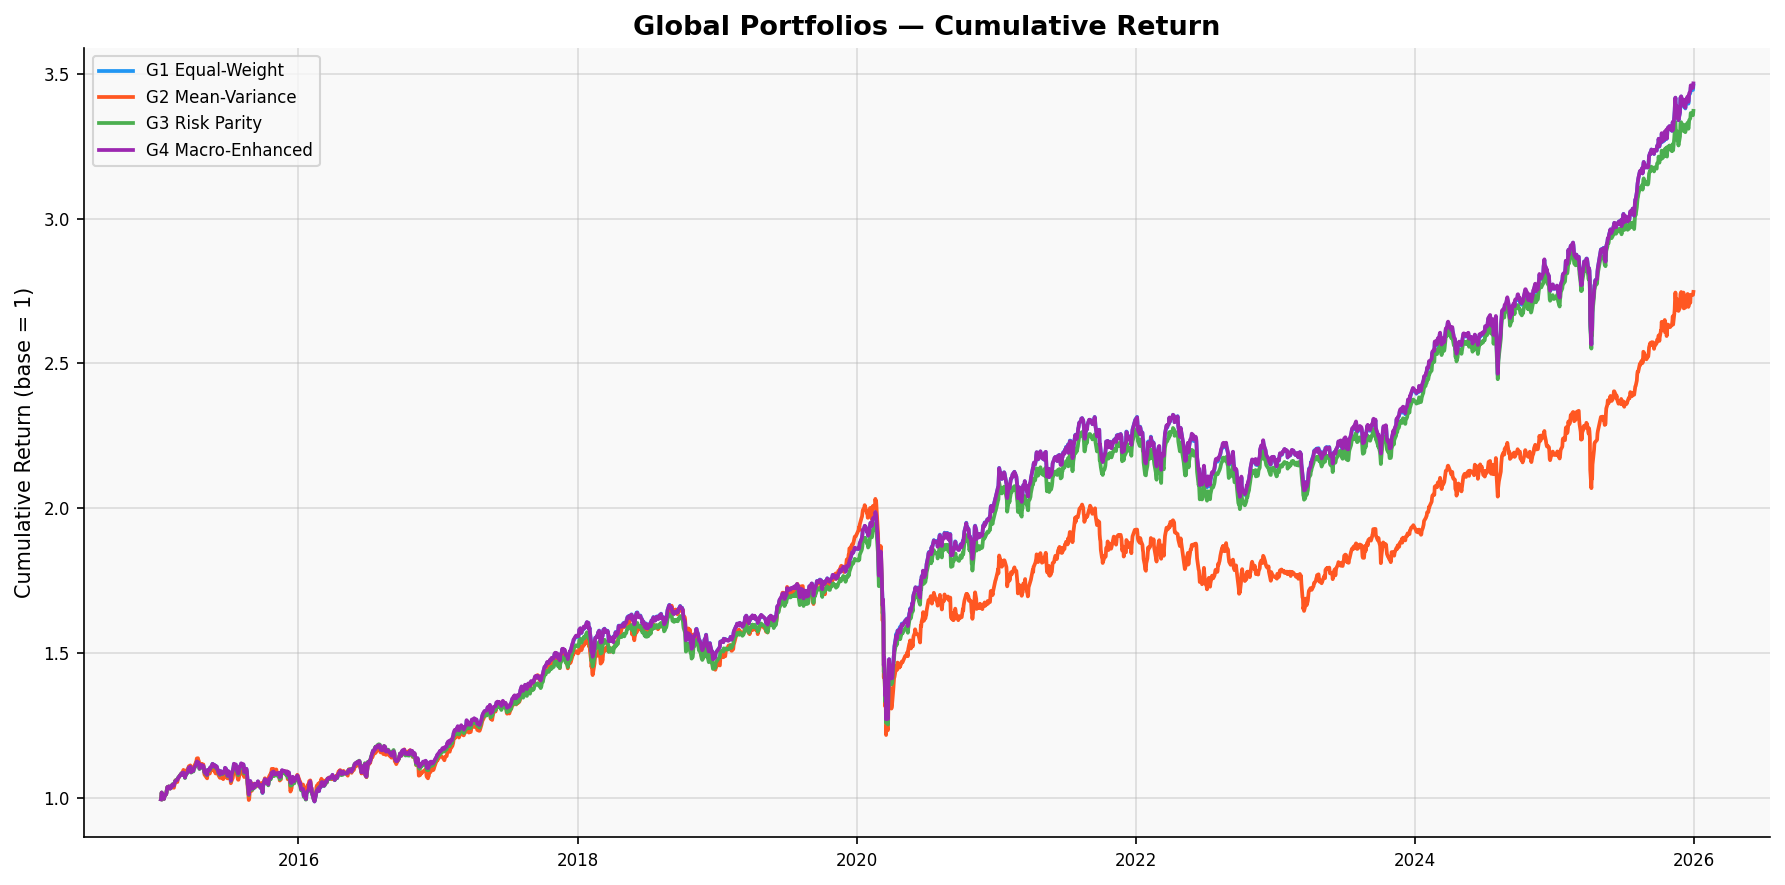


[Colored Global — Drawdown Comparison]


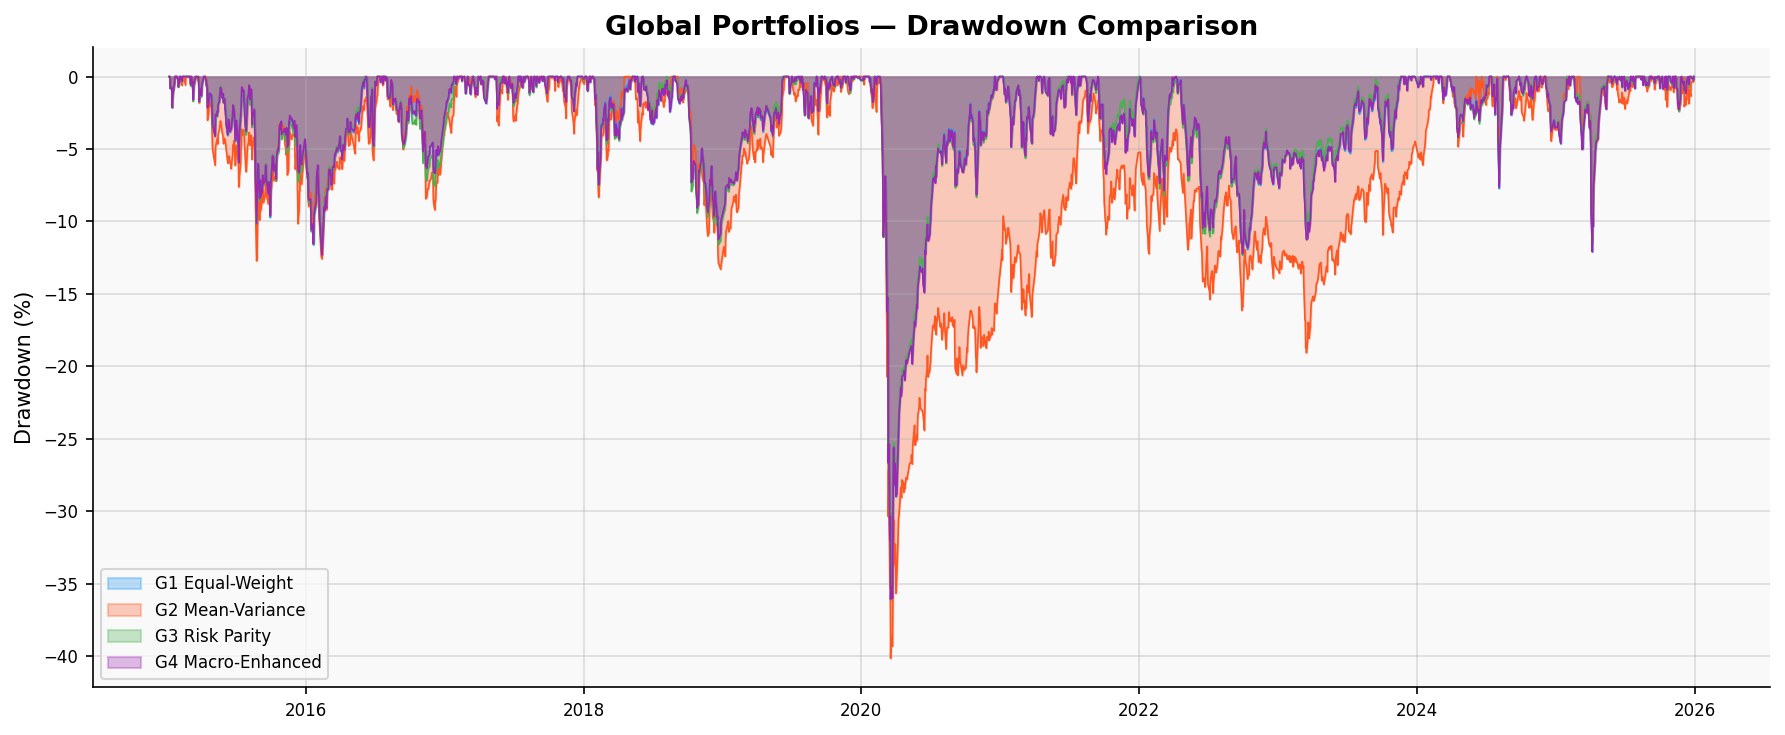


[Colored Global — Rolling Sharpe (126-day window)]


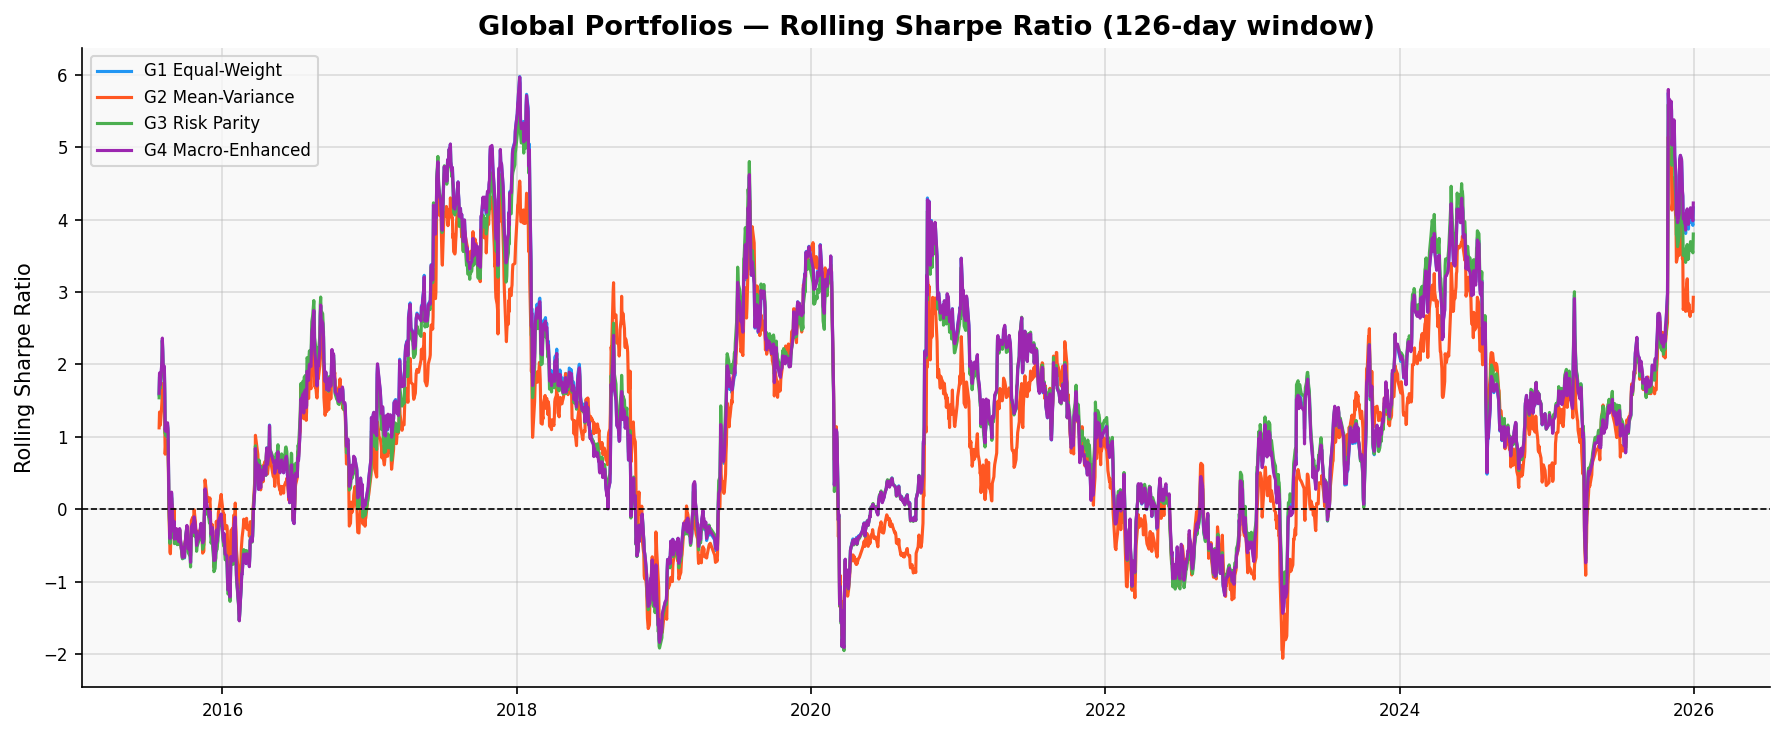


[Colored Global — Transaction Cost Robustness]


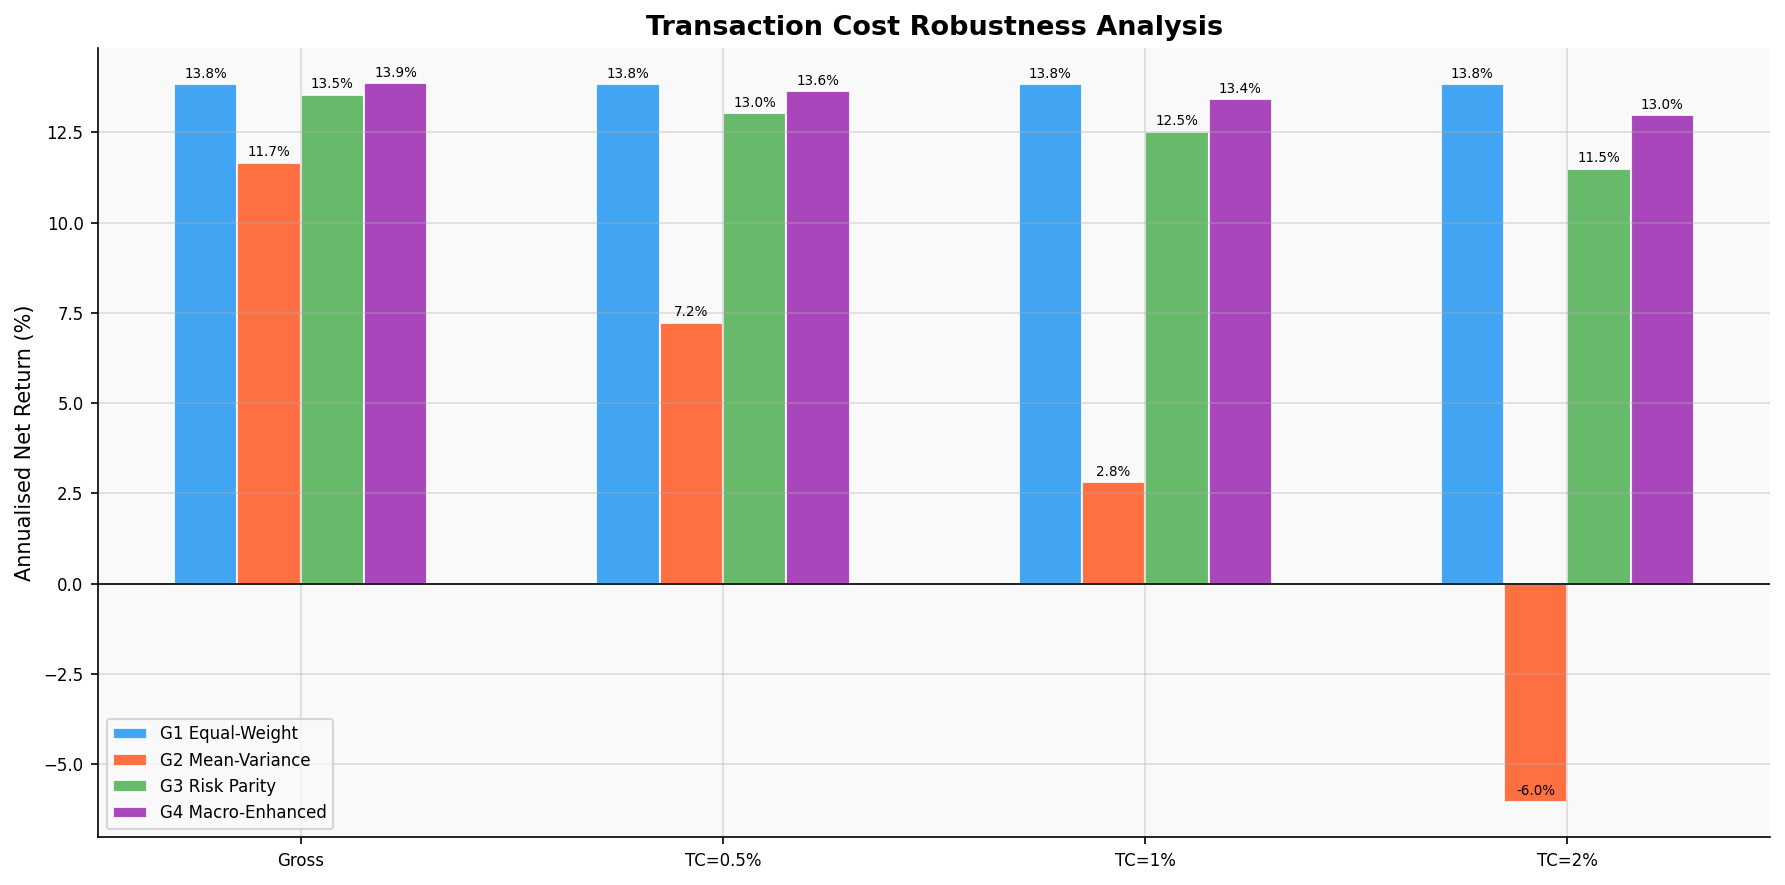

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# 1. Provide the EXACT matching dictionary keys for the colors
GLOBAL_COLORS = {
    "G1 Equal-Weight": "#2196F3",     # Blue
    "G2 Mean-Variance": "#FF5722",    # Orange
    "G3 Risk Parity": "#4CAF50",      # Green
    "G4 Macro-Enhanced": "#9C27B0"    # Purple
}

# 2. Redefine the plotting functions to use the new GLOBAL_COLORS mapping
def plot_cumulative_returns_colored(global_port_rets: dict) -> None:
    fig, ax = plt.subplots(figsize=(12, 6))
    for label, ret in global_port_rets.items():
        cum = (1 + ret).cumprod()
        ax.plot(cum.index, cum.values,
                label=label, color=GLOBAL_COLORS.get(label, "grey"), linewidth=1.8)
    ax.set_ylabel("Cumulative Return (base = 1)")
    ax.set_title("Global Portfolios — Cumulative Return", fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_drawdowns_colored(global_port_rets: dict) -> None:
    fig, ax = plt.subplots(figsize=(12, 5))
    for label, ret in global_port_rets.items():
        dd = drawdown_series(ret) * 100  # Assumes drawdown_series is already loaded in your environment
        ax.fill_between(dd.index, dd.values, 0,
                        alpha=0.3, color=GLOBAL_COLORS.get(label, "grey"), label=label)
        ax.plot(dd.index, dd.values, color=GLOBAL_COLORS.get(label, "grey"), linewidth=0.8)
    ax.set_ylabel("Drawdown (%)")
    ax.set_title("Global Portfolios — Drawdown Comparison", fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_rolling_sharpe_colored(global_port_rets: dict, window: int = 126) -> None:
    fig, ax = plt.subplots(figsize=(12, 5))
    for label, ret in global_port_rets.items():
        rs = rolling_sharpe(ret, window=window)  # Assumes rolling_sharpe is already loaded
        ax.plot(rs.index, rs.values,
                label=label, color=GLOBAL_COLORS.get(label, "grey"), linewidth=1.5)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel("Rolling Sharpe Ratio")
    ax.set_title(f"Global Portfolios — Rolling Sharpe Ratio ({window}-day window)", fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_tc_robustness_colored(global_port_rets: dict, global_turnovers: dict) -> None:
    fig, ax = plt.subplots(figsize=(12, 6))
    cost_vals = [0.0, 0.005, 0.01, 0.02]
    cost_labels = ["Gross", "TC=0.5%", "TC=1%", "TC=2%"]
    n_strategies = len(global_port_rets)
    x = np.arange(len(cost_vals))
    bar_w = 0.15

    for i, (label, ret) in enumerate(global_port_rets.items()):
        tv = global_turnovers[label]
        # Assumes annualise_return and apply_transaction_costs are already loaded
        net_rets = [annualise_return(apply_transaction_costs(ret, tv, c)) * 100 for c in cost_vals]
        offset = (i - n_strategies / 2) * bar_w + bar_w / 2

        bars = ax.bar(x + offset, net_rets, bar_w,
                      label=label, color=GLOBAL_COLORS.get(label, "grey"),
                      alpha=0.85, edgecolor="white")

        for bar, val in zip(bars, net_rets):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=6.5)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(cost_labels)
    ax.set_ylabel("Annualised Net Return (%)")
    ax.set_title("Transaction Cost Robustness Analysis", fontsize=13, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 3. RUN THE PLOTS USING YOUR EXISTING DATA
# ---------------------------------------------------------

print("\n[Colored Global — Cumulative Returns]")
plot_cumulative_returns_colored(global_port_rets)

print("\n[Colored Global — Drawdown Comparison]")
plot_drawdowns_colored(global_port_rets)

print("\n[Colored Global — Rolling Sharpe (126-day window)]")
plot_rolling_sharpe_colored(global_port_rets)

print("\n[Colored Global — Transaction Cost Robustness]")
plot_tc_robustness_colored(global_port_rets, global_turnovers)